In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Black spot/Image (36).png
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Black spot/Image (162).png
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Black spot/aug_11_Image (31).jpeg
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Black spot/Black spot (5).jpg
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Black spot/Image (157).png
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Black spot/Image (39).png
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Black spot/Image (48).png
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Black spot/Image (54).png
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Black spot/Image (85).png
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Black spot/Image (63).png
/kaggle/input/datasets/jhasvenijamis

In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for filename in files[:5]:
        print("   ", filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/jhasvenijamisetty
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Black spot
    Image (36).png
    Image (162).png
    aug_11_Image (31).jpeg
    Black spot (5).jpg
    Image (157).png
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Canker
    Image (36).png
    Canker (124).jpg
    Image (162).png
    aug_10_Image (82).jpeg
    9d4dd139-c1a9-4e5b-8cec-02afc3f49dfa.png
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Melanose
    aug_125_Image (9).jpeg
    aug_108_SAM_4840Catla.jpeg
    aug_77_SAM_3927Catla.jpeg
    aug_6_SAM_3929Catla.jpeg
    Melanose_60.jpg
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/Healthy
    h (154).jpg
    h (331).jpg
    Image (36).png
    h (118).jpg
    aug_89_Image (27).jpeg
/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset/G

In [4]:
import os

DATASET_PATH = "/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset"

classes = sorted([
    name for name in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, name))
])

print("Number of classes:", len(classes))
print("\nClass distribution:")

total_images = 0

for class_name in classes:
    class_path = os.path.join(DATASET_PATH, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    print(f"{class_name}: {len(images)} images")
    total_images += len(images)

print("\nTotal images:", total_images)

Number of classes: 5

Class distribution:
Black spot: 238 images
Canker: 237 images
Greening: 220 images
Healthy: 705 images
Melanose: 316 images

Total images: 1716


In [6]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("\nGPU available:")
    for gpu in gpus:
        print(gpu)
else:
    print("\nNo GPU detected. This notebook will use the CPU.")

TensorFlow version: 2.20.0

GPU available:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')


In [7]:
import os
from PIL import Image
from collections import Counter

DATASET_PATH = (
    "/kaggle/input/datasets/"
    "jhasvenijamisetty/citrus-leaf-disease-dataset"
)

class_counts = Counter()
bad_images = []

for class_name in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, class_name)

    if not os.path.isdir(class_path):
        continue

    for filename in os.listdir(class_path):
        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):
            filepath = os.path.join(class_path, filename)

            try:
                with Image.open(filepath) as img:
                    img.verify()
                class_counts[class_name] += 1
            except Exception as e:
                bad_images.append((filepath, str(e)))

print("CLASS COUNTS")
for name, count in sorted(class_counts.items()):
    print(f"{name}: {count}")

print("\nTOTAL VALID IMAGES:", sum(class_counts.values()))
print("DAMAGED IMAGES:", len(bad_images))

if bad_images:
    for path, error in bad_images[:10]:
        print(path, error)

CLASS COUNTS
Black spot: 238
Canker: 237
Greening: 220
Healthy: 705
Melanose: 316

TOTAL VALID IMAGES: 1716
DAMAGED IMAGES: 0


TensorFlow: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Classes: ['Black spot', 'Canker', 'Greening', 'Healthy', 'Melanose']
Total images: 1716

Training images: 1201
Validation images: 257
Testing images: 258


I0000 00:00:1791545510.153216      48 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791545510.157695      48 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ online_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 138ms/step - accuracy: 0.5529 - loss: 1.1697 - val_accuracy: 0.7938 - val_loss: 0.6140
Epoch 2/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.7727 - loss: 0.6047 - val_accuracy: 0.8288 - val_loss: 0.4496
Epoch 3/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.8276 - loss: 0.4543 - val_accuracy: 0.8638 - val_loss: 0.3695
Epoch 4/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.8526 - loss: 0.4061 - val_accuracy: 0.8833 - val_loss: 0.3331
Epoch 5/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.8426 - loss: 0.3744 - val_accuracy: 0.8911 - val_loss: 0.3095
Epoch 6/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.8876 - loss: 0.3190 - val_accuracy: 0.8949 - val_loss: 0.2991
Epoch 7/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.8909 - loss: 0.3007 - val_accuracy: 0.9027 - val_loss: 0.2631
Epoch 8/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.8934 - loss: 0.2806 - val_accuracy: 0.8988 - val_los

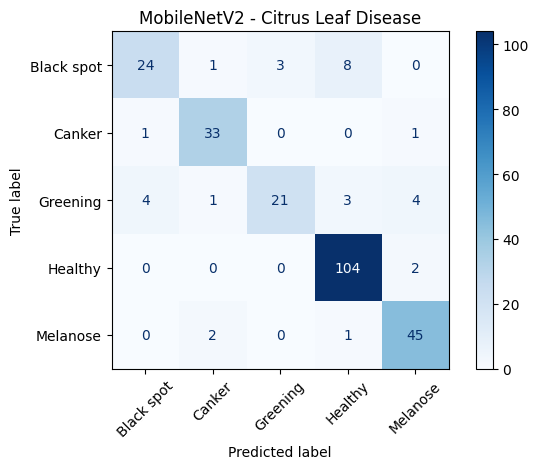

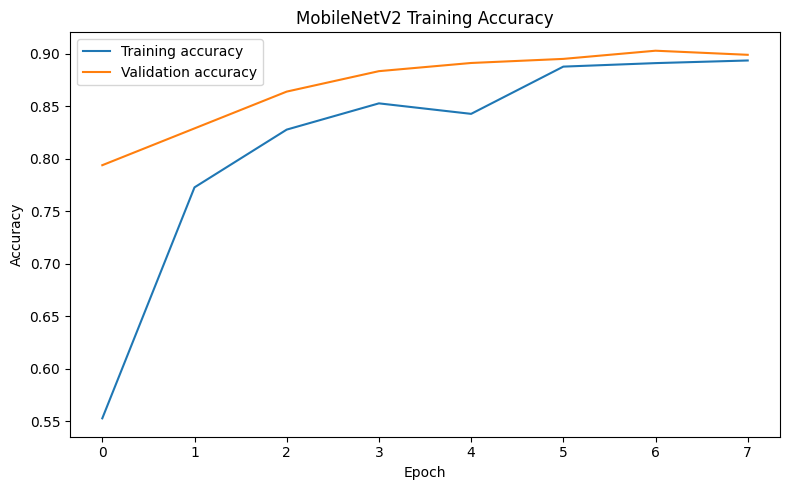


Training completed!
Results saved in: /kaggle/working/citrus_results

Files:
- accuracy_curve.png
- final_mobilenetv2.keras
- confusion_matrix.png
- classification_report.txt
- best_mobilenetv2.keras
- class_names.json


In [8]:
# ============================================================
# CITRUS LEAF DISEASE CLASSIFICATION
# MobileNetV2 + Online Data Augmentation
# ============================================================

import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

# -----------------------------
# 1. Configuration
# -----------------------------

DATASET_PATH = (
    "/kaggle/input/datasets/"
    "jhasvenijamisetty/citrus-leaf-disease-dataset"
)

OUTPUT_PATH = "/kaggle/working/citrus_results"
os.makedirs(OUTPUT_PATH, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 8
SEED = 42

tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

# -----------------------------
# 2. Load image paths and labels
# -----------------------------

class_names = sorted([
    name for name in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, name))
])

class_to_index = {
    name: index for index, name in enumerate(class_names)
}

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

image_paths = []
labels = []

for class_name in class_names:
    class_dir = os.path.join(DATASET_PATH, class_name)

    for filename in os.listdir(class_dir):
        if filename.lower().endswith(valid_extensions):
            image_paths.append(os.path.join(class_dir, filename))
            labels.append(class_to_index[class_name])

image_paths = np.array(image_paths)
labels = np.array(labels, dtype=np.int32)

print("\nClasses:", class_names)
print("Total images:", len(image_paths))

# -----------------------------
# 3. Split BEFORE augmentation
# -----------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("\nTraining images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

# -----------------------------
# 4. Decode and resize images
# -----------------------------

def load_image(path, label):
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label

def create_dataset(paths, targets, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, targets))

    if training:
        dataset = dataset.shuffle(
            len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    return dataset.prefetch(tf.data.AUTOTUNE)

train_ds = create_dataset(X_train, y_train, training=True)
val_ds = create_dataset(X_val, y_val)
test_ds = create_dataset(X_test, y_test)

# -----------------------------
# 5. Online augmentation
# -----------------------------

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10)
], name="online_augmentation")

# Augmentation is applied only during training.
# No augmented files are written to disk.

# -----------------------------
# 6. Build MobileNetV2
# -----------------------------

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.25)(x)

outputs = tf.keras.layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -----------------------------
# 7. Train
# -----------------------------

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_PATH, "best_mobilenetv2.keras"),
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# -----------------------------
# 8. Evaluate on test set
# -----------------------------

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("\nTest loss:", test_loss)
print("Test accuracy:", round(test_accuracy * 100, 2), "%")

probabilities = model.predict(test_ds)

y_pred = np.argmax(probabilities, axis=1)

print("\nClassification Report:")
report = classification_report(
    y_test,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0
)

print(report)

with open(
    os.path.join(OUTPUT_PATH, "classification_report.txt"),
    "w"
) as f:
    f.write(report)

# -----------------------------
# 9. Confusion matrix
# -----------------------------

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(len(class_names))
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(xticks_rotation=45, cmap="Blues")
plt.title("MobileNetV2 - Citrus Leaf Disease")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_PATH, "confusion_matrix.png"),
    dpi=150
)
plt.show()

# -----------------------------
# 10. Training curves
# -----------------------------

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_PATH, "accuracy_curve.png"),
    dpi=150
)
plt.show()

# -----------------------------
# 11. Save final model and metadata
# -----------------------------

model.save(
    os.path.join(OUTPUT_PATH, "final_mobilenetv2.keras")
)

with open(
    os.path.join(OUTPUT_PATH, "class_names.json"),
    "w"
) as f:
    json.dump(class_names, f, indent=2)

print("\nTraining completed!")
print("Results saved in:", OUTPUT_PATH)
print("\nFiles:")
for filename in os.listdir(OUTPUT_PATH):
    print("-", filename)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Black spot       0.83      0.67      0.74        36
      Canker       0.89      0.94      0.92        35
    Greening       0.88      0.64      0.74        33
     Healthy       0.90      0.98      0.94       106
    Melanose       0.87      0.94      0.90        48

    accuracy                           0.88       258
   macro avg       0.87      0.83      0.85       258
weighted avg       0.88      0.88      0.87       258


 accuracy_curve.png


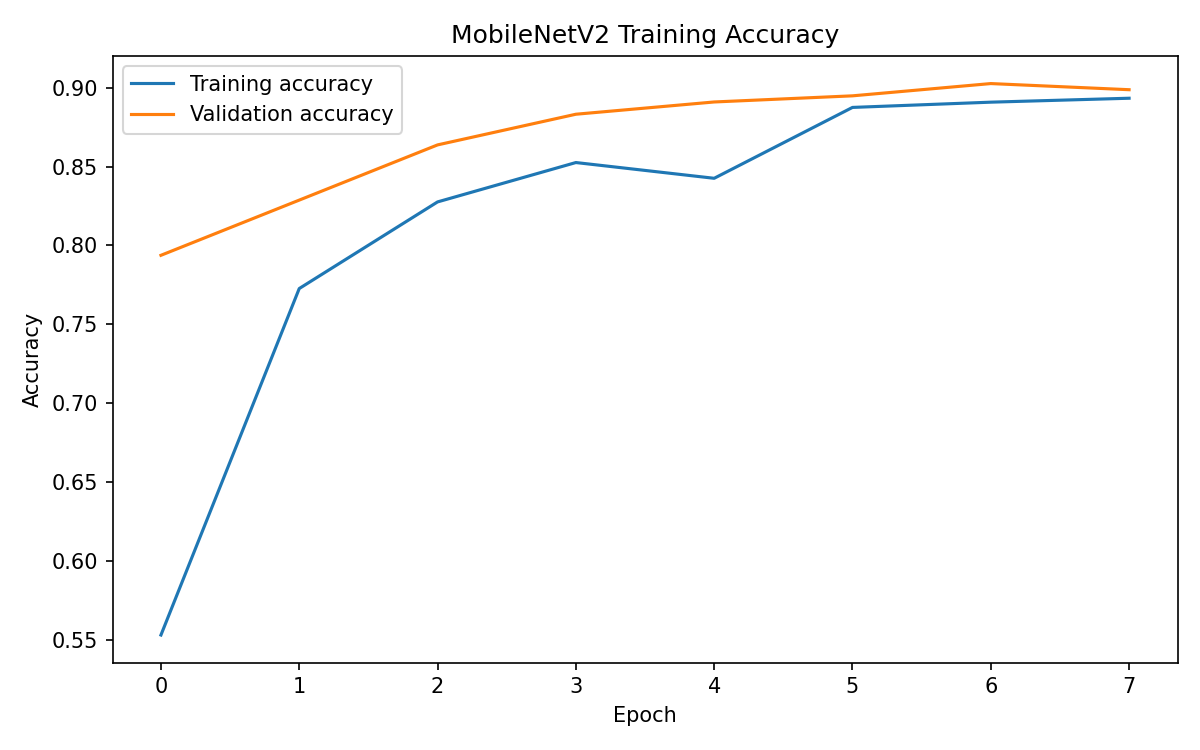


 confusion_matrix.png


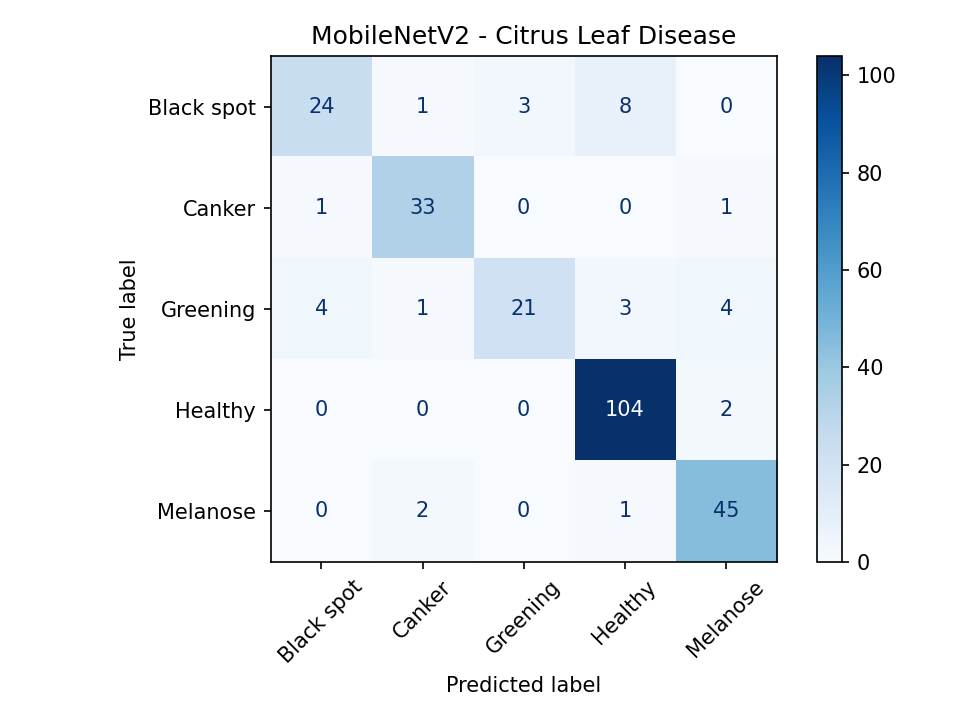

In [10]:
import os

RESULTS_PATH = "/kaggle/working/citrus_results"

# Display classification report
report_path = os.path.join(
    RESULTS_PATH,
    "classification_report.txt"
)

with open(report_path, "r") as f:
    print("CLASSIFICATION REPORT")
    print(f.read())

# Display training curves and confusion matrix
from IPython.display import display, Image

for filename in [
    "accuracy_curve.png",
    "confusion_matrix.png"
]:
    filepath = os.path.join(RESULTS_PATH, filename)
    print("\n", filename)
    display(Image(filename=filepath))

In [11]:
import shutil

shutil.make_archive(
    "/kaggle/working/citrus_project_results",
    "zip",
    "/kaggle/working/citrus_results"
)

print("Results ZIP created successfully.")

Results ZIP created successfully.


In [12]:
import os
import tensorflow as tf
import numpy as np

from sklearn.metrics import classification_report

RESULTS_PATH = "/kaggle/working/citrus_results"

# Rebuild the same architecture and load the best checkpoint.
# The architecture must match the first training experiment.

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10)
], name="online_augmentation")

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(5, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

best_path = os.path.join(
    RESULTS_PATH,
    "best_mobilenetv2.keras"
)

model.load_weights(best_path)

# Unfreeze the final portion of MobileNetV2.
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep batch-normalization layers frozen for stable fine-tuning.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(
            RESULTS_PATH,
            "best_mobilenetv2_finetuned.keras"
        ),
        monitor="val_loss",
        save_best_only=True
    )
]

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

print("\nFine-tuning completed.")

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - accuracy: 0.8876 - loss: 0.3021 - val_accuracy: 0.9066 - val_loss: 0.2441
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9067 - loss: 0.2398 - val_accuracy: 0.9105 - val_loss: 0.2460
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.9109 - loss: 0.2385 - val_accuracy: 0.9222 - val_loss: 0.2121
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.9151 - loss: 0.2184 - val_accuracy: 0.9300 - val_loss: 0.2022
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9292 - loss: 0.1948 - val_accuracy: 0.9222 - val_loss: 0.2055

Fine-tuning completed.


In [13]:
model = tf.keras.models.load_model(
    "/kaggle/working/citrus_results/best_mobilenetv2_finetuned.keras"
)

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

probabilities = model.predict(test_ds)
y_pred = np.argmax(probabilities, axis=1)

print(f"\nFine-tuned test accuracy: {test_accuracy * 100:.2f}%")

print(
    classification_report(
        y_test,
        y_pred,
        labels=np.arange(5),
        target_names=class_names,
        zero_division=0
    )
)

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.8992 - loss: 0.3207
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step

Fine-tuned test accuracy: 89.92%
              precision    recall  f1-score   support

  Black spot       0.95      0.58      0.72        36
      Canker       0.94      0.91      0.93        35
    Greening       0.83      0.88      0.85        33
     Healthy       0.90      0.99      0.94       106
    Melanose       0.90      0.94      0.92        48

    accuracy                           0.90       258
   macro avg       0.90      0.86      0.87       258
weighted avg       0.90      0.90      0.89       258



In [14]:
import os
import shutil

RESULTS_PATH = "/kaggle/working/citrus_results"

# Save the fine-tuned model
model.save(
    os.path.join(
        RESULTS_PATH,
        "final_mobilenetv2_finetuned.keras"
    )
)

# Package all current results
shutil.make_archive(
    "/kaggle/working/citrus_project_results",
    "zip",
    RESULTS_PATH
)

print("Fine-tuned model saved.")
print("Results ZIP updated.")

for filename in os.listdir(RESULTS_PATH):
    print("-", filename)

Fine-tuned model saved.
Results ZIP updated.
- final_mobilenetv2_finetuned.keras
- accuracy_curve.png
- final_mobilenetv2.keras
- confusion_matrix.png
- classification_report.txt
- best_mobilenetv2.keras
- best_mobilenetv2_finetuned.keras
- class_names.json


In [15]:
import os
import shutil

results_path = "/kaggle/working/citrus_results"

zip_path = shutil.make_archive(
    "/kaggle/working/citrus_project_results",
    "zip",
    results_path
)

print("ZIP file created:", zip_path)

ZIP file created: /kaggle/working/citrus_project_results.zip


In [16]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for filename in files:
        if filename.endswith(".zip") or filename.endswith(".keras"):
            print(os.path.join(root, filename))

/kaggle/working/citrus_project_results.zip
/kaggle/working/citrus_results/final_mobilenetv2_finetuned.keras
/kaggle/working/citrus_results/final_mobilenetv2.keras
/kaggle/working/citrus_results/best_mobilenetv2.keras
/kaggle/working/citrus_results/best_mobilenetv2_finetuned.keras


In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU count: 2


In [2]:
import torchvision

print("Torchvision version:", torchvision.__version__)

Torchvision version: 0.26.0+cu128


In [3]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --------------------------------------------------
# 1. Configuration
# --------------------------------------------------

DATASET_PATH = (
    "/kaggle/input/datasets/"
    "jhasvenijamisetty/citrus-leaf-disease-dataset"
)

OUTPUT_PATH = "/kaggle/working/citrus_resnet_results"
os.makedirs(OUTPUT_PATH, exist_ok=True)

SEED = 42
BATCH_SIZE = 32
EPOCHS = 8
IMAGE_SIZE = 224

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# --------------------------------------------------
# 2. Read dataset paths
# --------------------------------------------------

class_names = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

class_to_idx = {
    name: idx for idx, name in enumerate(class_names)
}

paths = []
labels = []

extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for class_name in class_names:
    folder = os.path.join(DATASET_PATH, class_name)

    for filename in os.listdir(folder):
        if filename.lower().endswith(extensions):
            paths.append(os.path.join(folder, filename))
            labels.append(class_to_idx[class_name])

paths = np.array(paths)
labels = np.array(labels, dtype=np.int64)

print("Classes:", class_to_idx)
print("Total images:", len(paths))

# --------------------------------------------------
# 3. Stratified train/validation/test split
# --------------------------------------------------

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Training:", len(train_paths))
print("Validation:", len(val_paths))
print("Testing:", len(test_paths))

# --------------------------------------------------
# 4. Online augmentation and preprocessing
# --------------------------------------------------

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.90, 1.10)
    ),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# --------------------------------------------------
# 5. Dataset class
# --------------------------------------------------

class CitrusLeafDataset(Dataset):
    def __init__(self, image_paths, labels, transform):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        image = self.transform(image)
        label = int(self.labels[idx])

        return image, label

train_dataset = CitrusLeafDataset(
    train_paths, train_labels, train_transform
)

val_dataset = CitrusLeafDataset(
    val_paths, val_labels, eval_transform
)

test_dataset = CitrusLeafDataset(
    test_paths, test_labels, eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# --------------------------------------------------
# 6. Class weights
# --------------------------------------------------

counts = np.bincount(
    train_labels,
    minlength=len(class_names)
)

weights = len(train_labels) / (
    len(class_names) * np.maximum(counts, 1)
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32,
    device=DEVICE
)

print("Class weights:", class_weights)

# --------------------------------------------------
# 7. Reference FruitResNet architecture
# --------------------------------------------------

weights = models.ResNet34_Weights.DEFAULT

base_model = models.resnet34(weights=weights)

# Freeze the pretrained backbone
for param in base_model.parameters():
    param.requires_grad = False

in_features = base_model.fc.in_features

base_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, len(class_names))
)

model = base_model.to(DEVICE)

# --------------------------------------------------
# 8. Optimizer, loss, and scheduler
# --------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0003
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=3
)

# --------------------------------------------------
# 9. Training and validation
# --------------------------------------------------

best_val_accuracy = 0.0

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0.0

    for images, targets in train_loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == targets).sum().item()
            total += targets.size(0)

    val_accuracy = correct / total
    avg_loss = total_loss / len(train_loader)

    scheduler.step(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {avg_loss:.4f} | "
        f"Validation accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save({
            "model_state": model.state_dict(),
            "class_mapping": class_to_idx,
            "accuracy": val_accuracy,
            "epoch": epoch + 1,
            "model_type": "resnet"
        }, os.path.join(OUTPUT_PATH, "resnet_best_model.pt"))

print("Best validation accuracy:", best_val_accuracy)

# --------------------------------------------------
# 10. Evaluate on the test set
# --------------------------------------------------

checkpoint = torch.load(
    os.path.join(OUTPUT_PATH, "resnet_best_model.pt"),
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state"])
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(DEVICE)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(targets.numpy())

print("\nTEST CLASSIFICATION REPORT")

report = classification_report(
    all_targets,
    all_predictions,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0
)

print(report)

print("CONFUSION MATRIX")
print(confusion_matrix(
    all_targets,
    all_predictions,
    labels=list(range(len(class_names)))
))

with open(
    os.path.join(OUTPUT_PATH, "classification_report.txt"),
    "w"
) as f:
    f.write(report)

print("\nResNet training and evaluation completed.")
print("Results saved to:", OUTPUT_PATH)

Device: cuda
GPU: Tesla T4
Classes: {'Black spot': 0, 'Canker': 1, 'Greening': 2, 'Healthy': 3, 'Melanose': 4}
Total images: 1716
Training: 1201
Validation: 257
Testing: 258
Class weights: tensor([1.4383, 1.4470, 1.5597, 0.4872, 1.0869], device='cuda:0')
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 182MB/s] 


Epoch 1/8 | Loss: 1.8910 | Validation accuracy: 0.2529
Epoch 2/8 | Loss: 1.6408 | Validation accuracy: 0.4241
Epoch 3/8 | Loss: 1.4783 | Validation accuracy: 0.5564
Epoch 4/8 | Loss: 1.3897 | Validation accuracy: 0.6031
Epoch 5/8 | Loss: 1.3065 | Validation accuracy: 0.6576
Epoch 6/8 | Loss: 1.2438 | Validation accuracy: 0.6304
Epoch 7/8 | Loss: 1.1833 | Validation accuracy: 0.6848
Epoch 8/8 | Loss: 1.1431 | Validation accuracy: 0.7043
Best validation accuracy: 0.7042801556420234

TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Black spot       0.54      0.75      0.63        36
      Canker       0.74      0.91      0.82        35
    Greening       0.56      0.67      0.61        33
     Healthy       0.95      0.74      0.83       106
    Melanose       0.89      0.81      0.85        48

    accuracy                           0.77       258
   macro avg       0.74      0.78      0.75       258
weighted avg       0.80      0.77      0.78       258

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

from sklearn.metrics import classification_report, confusion_matrix

# --------------------------------------------------
# 1. Configuration
# --------------------------------------------------

OUTPUT_PATH = "/kaggle/working/citrus_efficientnet_results"
os.makedirs(OUTPUT_PATH, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(class_names)
EPOCHS = 8

print("Device:", DEVICE)
print("Classes:", class_names)

# --------------------------------------------------
# 2. Reference FruitEfficientNet architecture
# --------------------------------------------------

class FruitEfficientNet(nn.Module):
    def __init__(self, num_classes, freeze_backbone=True):
        super().__init__()

        self.model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False

        in_features = self.model.classifier[1].in_features

        self.model.classifier[1] = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = FruitEfficientNet(NUM_CLASSES).to(DEVICE)

# --------------------------------------------------
# 3. Loss, optimizer and scheduler
# --------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE),
    label_smoothing=0.1
)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0003
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=3
)

# --------------------------------------------------
# 4. Training
# --------------------------------------------------

best_val_accuracy = 0.0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for images, targets in train_loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)

            predictions = model(images).argmax(dim=1)

            correct += (predictions == targets).sum().item()
            total += targets.size(0)

    val_accuracy = correct / total
    avg_loss = total_loss / len(train_loader)

    scheduler.step(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {avg_loss:.4f} | "
        f"Validation accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save(
            {
                "model_state": model.state_dict(),
                "class_mapping": class_to_idx,
                "accuracy": val_accuracy,
                "epoch": epoch + 1,
                "model_type": "efficientnet"
            },
            os.path.join(OUTPUT_PATH, "efficientnet_best_model.pt")
        )

print("\nBest validation accuracy:", best_val_accuracy)

# --------------------------------------------------
# 5. Evaluate the best checkpoint on the test set
# --------------------------------------------------

checkpoint = torch.load(
    os.path.join(OUTPUT_PATH, "efficientnet_best_model.pt"),
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(checkpoint["model_state"])
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(DEVICE)

        predictions = model(images).argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(targets.numpy())

print("\nTEST CLASSIFICATION REPORT")

report = classification_report(
    all_targets,
    all_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    zero_division=0
)

print(report)

print("\nCONFUSION MATRIX")

cm = confusion_matrix(
    all_targets,
    all_predictions,
    labels=list(range(NUM_CLASSES))
)

print(cm)

with open(
    os.path.join(OUTPUT_PATH, "classification_report.txt"),
    "w"
) as f:
    f.write(report)

print("\nEfficientNet-B0 training completed.")
print("Results saved to:", OUTPUT_PATH)

Device: cuda
Classes: ['Black spot', 'Canker', 'Greening', 'Healthy', 'Melanose']
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 117MB/s] 


Epoch 1/8 | Loss: 1.5636 | Validation accuracy: 0.6615
Epoch 2/8 | Loss: 1.3273 | Validation accuracy: 0.7938
Epoch 3/8 | Loss: 1.1707 | Validation accuracy: 0.8016
Epoch 4/8 | Loss: 1.0700 | Validation accuracy: 0.8482
Epoch 5/8 | Loss: 1.0203 | Validation accuracy: 0.8560
Epoch 6/8 | Loss: 0.9659 | Validation accuracy: 0.8521
Epoch 7/8 | Loss: 0.9408 | Validation accuracy: 0.8638
Epoch 8/8 | Loss: 0.9000 | Validation accuracy: 0.8638

Best validation accuracy: 0.8638132295719845

TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Black spot       0.86      0.69      0.77        36
      Canker       0.82      0.94      0.88        35
    Greening       0.69      0.88      0.77        33
     Healthy       0.99      0.90      0.94       106
    Melanose       0.88      0.94      0.91        48

    accuracy                           0.88       258
   macro avg       0.85      0.87      0.85       258
weighted avg       0.89      0.88      0.88       25

In [5]:
import os

for folder in [
    "/kaggle/working/citrus_resnet_results",
    "/kaggle/working/citrus_efficientnet_results",
    "/kaggle/working/citrus_results"
]:
    print(f"\n{'=' * 55}")
    print(folder)

    if os.path.exists(folder):
        for root, dirs, files in os.walk(folder):
            for file in files:
                path = os.path.join(root, file)
                print(f"{file} — {os.path.getsize(path) / (1024 * 1024):.2f} MB")
    else:
        print("Folder not found in this Kaggle session.")


/kaggle/working/citrus_resnet_results
resnet_best_model.pt — 81.34 MB
classification_report.txt — 0.00 MB

/kaggle/working/citrus_efficientnet_results
efficientnet_best_model.pt — 15.61 MB
classification_report.txt — 0.00 MB

/kaggle/working/citrus_results
Folder not found in this Kaggle session.


In [6]:
import os
import shutil

BASE = "/kaggle/working"
PACKAGE = os.path.join(BASE, "citrus_project_package")

os.makedirs(PACKAGE, exist_ok=True)

folders = {
    "ResNet34": os.path.join(BASE, "citrus_resnet_results"),
    "EfficientNet_B0": os.path.join(BASE, "citrus_efficientnet_results"),
}

for model_name, source_folder in folders.items():
    destination = os.path.join(PACKAGE, model_name)
    os.makedirs(destination, exist_ok=True)

    if os.path.exists(source_folder):
        for filename in os.listdir(source_folder):
            source = os.path.join(source_folder, filename)

            if os.path.isfile(source):
                shutil.copy2(
                    source,
                    os.path.join(destination, filename)
                )

print("Available model results copied.")

zip_path = shutil.make_archive(
    os.path.join(BASE, "citrus_project_package"),
    "zip",
    PACKAGE
)

print("ZIP created:", zip_path)
print("ZIP size:", round(os.path.getsize(zip_path) / (1024 * 1024), 2), "MB")

Available model results copied.
ZIP created: /kaggle/working/citrus_project_package.zip
ZIP size: 89.83 MB


In [7]:
!git clone https://github.com/Guna266/citrus-fruit-disease-classification.git /kaggle/working/reference_repo

Cloning into '/kaggle/working/reference_repo'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (37/37), done.(15/37)
remote: Total 51 (delta 8), reused 51 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 15.19 KiB | 1.26 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [8]:
import os

REPO = "/kaggle/working/reference_repo"

for root, dirs, files in os.walk(REPO):
    dirs[:] = [d for d in dirs if d not in [".git", "__pycache__"]]
    level = root.replace(REPO, "").count(os.sep)

    if level <= 3:
        print("  " * level + os.path.basename(root) + "/")

        if level < 3:
            for file in files:
                print("  " * (level + 1) + file)

reference_repo/
  README.md
  .gitignore
  requirements.txt
  scripts/
    split_sequential.py
  models/
    efficientnet_model.py
    mobilenet_model.py
    vit_model.py
    swin_model.py
    resnet_model.py
    convnext_model.py
    mobilevit_model.py
  app/
    main.py
    utils/
      class_map.py
      preprocess.py
    core/
      model_loader.py
    schema/
      prediction_schema.py
    api/
      classes.py
      model_info.py
      routes.py
      predict.py
      health.py
    services/
      inference_service.py
  data/
    transforms.py
    dataset.py
    dataloader.py
  training/
    trainer.py
    evaluate.py
    train.py
    utils/
      class_weights.py


In [9]:
import os

REPO = "/kaggle/working/reference_repo"

files_to_inspect = [
    "models/vit_model.py",
    "models/mobilenet_model.py",
    "models/convnext_model.py",
    "models/swin_model.py",
    "models/mobilevit_model.py",
    "data/dataset.py",
    "data/transforms.py",
    "data/dataloader.py",
    "training/train.py",
    "training/trainer.py",
    "training/evaluate.py",
    "training/utils/class_weights.py",
]

for relative_path in files_to_inspect:
    full_path = os.path.join(REPO, relative_path)

    print("\n" + "=" * 80)
    print(f"FILE: {relative_path}")
    print("=" * 80)

    if os.path.exists(full_path):
        with open(full_path, "r", encoding="utf-8") as f:
            print(f.read())
    else:
        print("FILE NOT FOUND")


FILE: models/vit_model.py
import torch.nn as nn
from torchvision.models import vit_b_16, ViT_B_16_Weights


class FruitViT(nn.Module):

    def __init__(self, num_classes, freeze_backbone=True):
        super().__init__()

        self.model = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)

        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False  

        in_features = self.model.heads.head.in_features
        self.model.heads.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)


FILE: models/mobilenet_model.py
import torch.nn as nn
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights


class FruitMobileNet(nn.Module):

    def __init__(self, num_classes, freeze_backbone=True):
        super().__init__()

        self.model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)

        if freeze_backbone:
            for param in self.model.

In [10]:
import os
import torch

DATA_DIR = "/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset"

print("Dataset exists:", os.path.exists(DATA_DIR))
print("\nDataset contents:")

for item in os.listdir(DATA_DIR):
    path = os.path.join(DATA_DIR, item)
    print(item, "->", "directory" if os.path.isdir(path) else "file")

print("\nExisting checkpoints:")

for folder in [
    "/kaggle/working/citrus_resnet_results",
    "/kaggle/working/citrus_efficientnet_results",
    "/kaggle/working/citrus_project_package"
]:
    print("\n", folder)
    if os.path.isdir(folder):
        for name in os.listdir(folder):
            print("  ", name)
    else:
        print("   Not found")

Dataset exists: True

Dataset contents:
Black spot -> directory
Canker -> directory
Melanose -> directory
Healthy -> directory
Greening -> directory

Existing checkpoints:

 /kaggle/working/citrus_resnet_results
   resnet_best_model.pt
   classification_report.txt

 /kaggle/working/citrus_efficientnet_results
   efficientnet_best_model.pt
   classification_report.txt

 /kaggle/working/citrus_project_package
   EfficientNet_B0
   ResNet34


In [11]:
import os
import torch
from collections import Counter

DATA_DIR = "/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset"

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

print("\nDataset class counts:")

for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)

    if os.path.isdir(class_path):
        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ]
        print(f"{class_name}: {len(images)}")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB

Dataset class counts:
Black spot: 238
Canker: 237
Greening: 220
Healthy: 705
Melanose: 316


In [12]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from pathlib import Path
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt

# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_DIR = "/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset"
OUT_DIR = "/kaggle/working/citrus_vit_results"

os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
BATCH_SIZE = 16
EPOCHS = 8
LEARNING_RATE = 0.0003

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ============================================================
# 2. COLLECT IMAGES FROM YOUR DATASET
# ============================================================

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

class_names = sorted([
    name for name in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, name))
])

class_to_idx = {
    name: index for index, name in enumerate(class_names)
}

samples = []

for class_name in class_names:
    class_dir = os.path.join(DATA_DIR, class_name)

    for root, _, files in os.walk(class_dir):
        for filename in sorted(files):
            if Path(filename).suffix.lower() in VALID_EXTENSIONS:
                path = os.path.join(root, filename)
                samples.append((path, class_to_idx[class_name]))

print("\nClass mapping:", class_to_idx)
print("Total images:", len(samples))
print("Class counts:", Counter(label for _, label in samples))

# ============================================================
# 3. CREATE STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

paths = np.array([p for p, _ in samples])
labels = np.array([y for _, y in samples])

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("\nSplit sizes:")
print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

# Save the exact split so it can be reused for the remaining models.
split_file = os.path.join(OUT_DIR, "data_split.csv")

split_df = pd.DataFrame({
    "path": list(train_paths) + list(val_paths) + list(test_paths),
    "label": list(train_labels) + list(val_labels) + list(test_labels),
    "split": (
        ["train"] * len(train_paths)
        + ["validation"] * len(val_paths)
        + ["test"] * len(test_paths)
    )
})

split_df.to_csv(split_file, index=False)
print("Saved split:", split_file)

# ============================================================
# 4. TRANSFORMS — ONLINE AUGMENTATION
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CitrusDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        image = self.transform(image)
        return image, int(self.labels[idx])

train_dataset = CitrusDataset(
    train_paths, train_labels, train_transform
)
val_dataset = CitrusDataset(
    val_paths, val_labels, eval_transform
)
test_dataset = CitrusDataset(
    test_paths, test_labels, eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# ============================================================
# 5. REPOSITORY ViT ARCHITECTURE
# ============================================================

class FruitViT(nn.Module):
    def __init__(self, num_classes, freeze_backbone=True):
        super().__init__()

        self.model = vit_b_16(
            weights=ViT_B_16_Weights.DEFAULT
        )

        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False

        in_features = self.model.heads.head.in_features
        self.model.heads.head = nn.Linear(
            in_features, num_classes
        )

    def forward(self, x):
        return self.model(x)

model = FruitViT(
    num_classes=len(class_names),
    freeze_backbone=True
).to(DEVICE)

print("\nViT model initialized.")

# ============================================================
# 6. CLASS WEIGHTS AND OPTIMIZER
# ============================================================

counts = Counter(train_labels.tolist())
total = len(train_labels)
num_classes = len(class_names)

class_weights = torch.tensor(
    [
        total / (num_classes * counts[i])
        for i in range(num_classes)
    ],
    dtype=torch.float32
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=3
)

# ============================================================
# 7. TRAINING LOOP
# ============================================================

best_val_accuracy = 0.0
history = []
best_checkpoint_path = os.path.join(
    OUT_DIR, "vit_best_model.pt"
)

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, targets in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_dataset)

    model.eval()
    val_predictions = []
    val_targets = []

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(DEVICE, non_blocking=True)

            outputs = model(images)
            predictions = outputs.argmax(dim=1).cpu().numpy()

            val_predictions.extend(predictions)
            val_targets.extend(targets.numpy())

    val_accuracy = accuracy_score(
        val_targets, val_predictions
    )

    scheduler.step(val_accuracy)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "validation_accuracy": val_accuracy,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Validation accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save({
            "model_state": model.state_dict(),
            "class_mapping": class_to_idx,
            "accuracy": val_accuracy,
            "epoch": epoch + 1,
            "model_type": "vit",
            "seed": SEED
        }, best_checkpoint_path)

elapsed_seconds = time.time() - start_time

print("\nBest validation accuracy:", best_val_accuracy)
print("Training time:", round(elapsed_seconds / 60, 2), "minutes")

# ============================================================
# 8. RESTORE BEST CHECKPOINT AND EVALUATE TEST SET
# ============================================================

checkpoint = torch.load(
    best_checkpoint_path,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(checkpoint["model_state"])
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(DEVICE, non_blocking=True)

        outputs = model(images)
        predictions = outputs.argmax(dim=1).cpu().numpy()

        all_predictions.extend(predictions)
        all_targets.extend(targets.numpy())

test_accuracy = accuracy_score(
    all_targets, all_predictions
)

report = classification_report(
    all_targets,
    all_predictions,
    labels=list(range(num_classes)),
    target_names=class_names,
    digits=4,
    zero_division=0
)

cm = confusion_matrix(
    all_targets,
    all_predictions,
    labels=list(range(num_classes))
)

print("\nTEST ACCURACY:", round(test_accuracy * 100, 2), "%")
print("\nCLASSIFICATION REPORT\n")
print(report)
print("\nCONFUSION MATRIX\n")
print(cm)

# ============================================================
# 9. SAVE RESULTS
# ============================================================

with open(
    os.path.join(OUT_DIR, "classification_report.txt"),
    "w"
) as f:
    f.write(f"Best validation accuracy: {best_val_accuracy:.6f}\n")
    f.write(f"Test accuracy: {test_accuracy:.6f}\n")
    f.write(f"Training duration seconds: {elapsed_seconds:.2f}\n\n")
    f.write(report)
    f.write("\nConfusion matrix:\n")
    f.write(np.array2string(cm))

with open(
    os.path.join(OUT_DIR, "class_mapping.json"),
    "w"
) as f:
    json.dump(class_to_idx, f, indent=4)

pd.DataFrame(history).to_csv(
    os.path.join(OUT_DIR, "training_history.csv"),
    index=False
)

# Plot training loss and validation accuracy.
fig, ax1 = plt.subplots(figsize=(9, 5))

epochs = [item["epoch"] for item in history]
losses = [item["train_loss"] for item in history]
accuracies = [
    item["validation_accuracy"] * 100 for item in history
]

ax1.plot(epochs, losses, marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training loss")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(epochs, accuracies, marker="s")
ax2.set_ylabel("Validation accuracy (%)")

plt.title("ViT Training History")
fig.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "training_history.png"),
    dpi=160
)
plt.close(fig)

# Save a readable confusion matrix image.
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm)

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("ViT Confusion Matrix")

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax)
fig.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "confusion_matrix.png"),
    dpi=160
)
plt.close(fig)

# Save prediction-level results for later analysis.
pd.DataFrame({
    "true_label": [class_names[i] for i in all_targets],
    "predicted_label": [class_names[i] for i in all_predictions]
}).to_csv(
    os.path.join(OUT_DIR, "test_predictions.csv"),
    index=False
)

print("\nViT training and evaluation completed.")
print("Results folder:", OUT_DIR)
print("\nFiles:")
for filename in sorted(os.listdir(OUT_DIR)):
    path = os.path.join(OUT_DIR, filename)
    print(
        filename,
        f"({os.path.getsize(path) / (1024 * 1024):.2f} MB)"
    )

Device: cuda
GPU: Tesla T4

Class mapping: {'Black spot': 0, 'Canker': 1, 'Greening': 2, 'Healthy': 3, 'Melanose': 4}
Total images: 1716
Class counts: Counter({3: 705, 4: 316, 0: 238, 1: 237, 2: 220})

Split sizes:
Train: 1201
Validation: 257
Test: 258
Saved split: /kaggle/working/citrus_vit_results/data_split.csv
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 210MB/s]  



ViT model initialized.
Epoch 1/8 | Loss: 1.3875 | Validation accuracy: 0.7704
Epoch 2/8 | Loss: 1.0216 | Validation accuracy: 0.7860
Epoch 3/8 | Loss: 0.9009 | Validation accuracy: 0.7977
Epoch 4/8 | Loss: 0.8504 | Validation accuracy: 0.8249
Epoch 5/8 | Loss: 0.8070 | Validation accuracy: 0.8327
Epoch 6/8 | Loss: 0.7897 | Validation accuracy: 0.8677
Epoch 7/8 | Loss: 0.7508 | Validation accuracy: 0.8638
Epoch 8/8 | Loss: 0.7480 | Validation accuracy: 0.8833

Best validation accuracy: 0.8832684824902723
Training time: 7.13 minutes

TEST ACCURACY: 88.76 %

CLASSIFICATION REPORT

              precision    recall  f1-score   support

  Black spot     0.7576    0.6944    0.7246        36
      Canker     0.8824    0.8571    0.8696        35
    Greening     0.6591    0.8788    0.7532        33
     Healthy     0.9900    0.9340    0.9612       106
    Melanose     0.9787    0.9583    0.9684        48

    accuracy                         0.8876       258
   macro avg     0.8535    0.8645 

In [13]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from pathlib import Path
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    mobilenet_v3_large,
    MobileNet_V3_Large_Weights
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt

# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_DIR = "/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset"
SPLIT_FILE = "/kaggle/working/citrus_vit_results/data_split.csv"
OUT_DIR = "/kaggle/working/citrus_mobilenet_results"

os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
BATCH_SIZE = 32
EPOCHS = 8
LEARNING_RATE = 0.0003

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)

# ============================================================
# 2. LOAD THE EXACT SPLIT USED FOR ViT
# ============================================================

if not os.path.exists(SPLIT_FILE):
    raise FileNotFoundError(
        "ViT data_split.csv not found. Preserve the ViT results first."
    )

split_df = pd.read_csv(SPLIT_FILE)

class_names = sorted([
    name for name in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, name))
])

class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

# Check that every saved path and label matches the dataset.
for row in split_df.itertuples(index=False):
    if not os.path.isfile(row.path):
        raise FileNotFoundError(f"Image not found: {row.path}")

    expected_class = os.path.basename(os.path.dirname(row.path))
    if class_to_idx[expected_class] != int(row.label):
        raise ValueError(f"Label mismatch for: {row.path}")

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df = split_df[split_df["split"] == "validation"].reset_index(drop=True)
test_df = split_df[split_df["split"] == "test"].reset_index(drop=True)

print("Classes:", class_names)
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# ============================================================
# 3. TRANSFORMS — ONLINE AUGMENTATION
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CitrusDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.paths = dataframe["path"].tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        with Image.open(self.paths[idx]) as image:
            image = image.convert("RGB")
            image = self.transform(image)

        return image, self.labels[idx]

train_dataset = CitrusDataset(train_df, train_transform)
val_dataset = CitrusDataset(val_df, eval_transform)
test_dataset = CitrusDataset(test_df, eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# ============================================================
# 4. REPOSITORY MOBILENETV3-LARGE ARCHITECTURE
# ============================================================

class FruitMobileNet(nn.Module):
    def __init__(self, num_classes, freeze_backbone=True):
        super().__init__()

        self.model = mobilenet_v3_large(
            weights=MobileNet_V3_Large_Weights.DEFAULT
        )

        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False

        in_features = self.model.classifier[3].in_features
        self.model.classifier[3] = nn.Linear(
            in_features, num_classes
        )

    def forward(self, x):
        return self.model(x)

model = FruitMobileNet(
    num_classes=len(class_names),
    freeze_backbone=True
).to(DEVICE)

print("\nMobileNetV3-Large initialized.")

# ============================================================
# 5. CLASS WEIGHTS, LOSS AND OPTIMIZER
# ============================================================

counts = Counter(train_df["label"].astype(int).tolist())
total = len(train_df)
num_classes = len(class_names)

class_weights = torch.tensor([
    total / (num_classes * counts[i])
    for i in range(num_classes)
], dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=3
)

# ============================================================
# 6. TRAIN
# ============================================================

best_val_accuracy = -1.0
history = []
checkpoint_path = os.path.join(
    OUT_DIR, "mobilenet_best_model.pt"
)

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, targets in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_dataset)

    model.eval()
    val_predictions = []
    val_targets = []

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(DEVICE, non_blocking=True)

            outputs = model(images)
            val_predictions.extend(
                outputs.argmax(dim=1).cpu().tolist()
            )
            val_targets.extend(targets.tolist())

    val_accuracy = accuracy_score(val_targets, val_predictions)
    scheduler.step(val_accuracy)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "validation_accuracy": val_accuracy,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Validation accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save({
            "model_state": model.state_dict(),
            "class_mapping": class_to_idx,
            "accuracy": val_accuracy,
            "epoch": epoch + 1,
            "model_type": "mobilenet",
            "seed": SEED
        }, checkpoint_path)

elapsed_seconds = time.time() - start_time

print("\nBest validation accuracy:", best_val_accuracy)
print("Training time:", round(elapsed_seconds / 60, 2), "minutes")

# ============================================================
# 7. RESTORE BEST CHECKPOINT AND EVALUATE TEST SET
# ============================================================

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(checkpoint["model_state"])
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)

        all_predictions.extend(
            outputs.argmax(dim=1).cpu().tolist()
        )
        all_targets.extend(targets.tolist())

test_accuracy = accuracy_score(all_targets, all_predictions)

report = classification_report(
    all_targets,
    all_predictions,
    labels=list(range(num_classes)),
    target_names=class_names,
    digits=4,
    zero_division=0
)

cm = confusion_matrix(
    all_targets,
    all_predictions,
    labels=list(range(num_classes))
)

print("\nTEST ACCURACY:", round(test_accuracy * 100, 2), "%")
print("\nCLASSIFICATION REPORT\n")
print(report)
print("\nCONFUSION MATRIX\n")
print(cm)

# ============================================================
# 8. SAVE ALL RESULTS
# ============================================================

with open(os.path.join(OUT_DIR, "classification_report.txt"), "w") as f:
    f.write(f"Best validation accuracy: {best_val_accuracy:.6f}\n")
    f.write(f"Test accuracy: {test_accuracy:.6f}\n")
    f.write(f"Training duration seconds: {elapsed_seconds:.2f}\n\n")
    f.write(report)
    f.write("\nConfusion matrix:\n")
    f.write(np.array2string(cm))

with open(os.path.join(OUT_DIR, "class_mapping.json"), "w") as f:
    json.dump(class_to_idx, f, indent=4)

pd.DataFrame(history).to_csv(
    os.path.join(OUT_DIR, "training_history.csv"),
    index=False
)

pd.DataFrame({
    "true_label": [idx_to_class[i] for i in all_targets],
    "predicted_label": [idx_to_class[i] for i in all_predictions]
}).to_csv(
    os.path.join(OUT_DIR, "test_predictions.csv"),
    index=False
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(cm)
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("MobileNetV3-Large Confusion Matrix")

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "confusion_matrix.png"),
    dpi=160
)
plt.close(fig)

pd.DataFrame(history).plot(
    x="epoch",
    y=["train_loss", "validation_accuracy"],
    marker="o",
    figsize=(8, 5)
)
plt.title("MobileNetV3-Large Training History")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "training_history.png"),
    dpi=160
)
plt.close()

print("\nMobileNetV3-Large completed.")
print("Results saved to:", OUT_DIR)

for filename in sorted(os.listdir(OUT_DIR)):
    path = os.path.join(OUT_DIR, filename)
    print(
        filename,
        f"({os.path.getsize(path) / (1024 * 1024):.2f} MB)"
    )

Device: cuda
Classes: ['Black spot', 'Canker', 'Greening', 'Healthy', 'Melanose']
Train: 1201
Validation: 257
Test: 258
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 83.9MB/s]



MobileNetV3-Large initialized.
Epoch 1/8 | Loss: 1.5314 | Validation accuracy: 0.5175
Epoch 2/8 | Loss: 1.3274 | Validation accuracy: 0.5914
Epoch 3/8 | Loss: 1.1844 | Validation accuracy: 0.6498
Epoch 4/8 | Loss: 1.1005 | Validation accuracy: 0.6615
Epoch 5/8 | Loss: 1.0394 | Validation accuracy: 0.6887
Epoch 6/8 | Loss: 0.9826 | Validation accuracy: 0.7160
Epoch 7/8 | Loss: 0.9604 | Validation accuracy: 0.7237
Epoch 8/8 | Loss: 0.9337 | Validation accuracy: 0.7315

Best validation accuracy: 0.7315175097276264
Training time: 1.16 minutes

TEST ACCURACY: 77.52 %

CLASSIFICATION REPORT

              precision    recall  f1-score   support

  Black spot     0.6818    0.4167    0.5172        36
      Canker     0.7381    0.8857    0.8052        35
    Greening     0.4429    0.9394    0.6019        33
     Healthy     1.0000    0.7358    0.8478       106
    Melanose     0.9783    0.9375    0.9574        48

    accuracy                         0.7752       258
   macro avg     0.7682   

In [14]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_DIR = "/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset"
SPLIT_FILE = "/kaggle/working/citrus_vit_results/data_split.csv"
OUT_DIR = "/kaggle/working/citrus_convnext_results"

os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
BATCH_SIZE = 16
EPOCHS = 8
LEARNING_RATE = 0.0003

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)

# ============================================================
# 2. LOAD THE SHARED DATA SPLIT
# ============================================================

if not os.path.exists(SPLIT_FILE):
    raise FileNotFoundError(f"Split file not found: {SPLIT_FILE}")

split_df = pd.read_csv(SPLIT_FILE)

class_names = sorted([
    name for name in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, name))
])

class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

for row in split_df.itertuples(index=False):
    if not os.path.isfile(row.path):
        raise FileNotFoundError(f"Image not found: {row.path}")

    parent_class = os.path.basename(os.path.dirname(row.path))
    if class_to_idx[parent_class] != int(row.label):
        raise ValueError(f"Label mismatch: {row.path}")

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df = split_df[split_df["split"] == "validation"].reset_index(drop=True)
test_df = split_df[split_df["split"] == "test"].reset_index(drop=True)

print("Classes:", class_names)
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# ============================================================
# 3. TRANSFORMS
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CitrusDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.paths = dataframe["path"].tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        with Image.open(self.paths[index]) as image:
            image = image.convert("RGB")
            image = self.transform(image)

        return image, self.labels[index]

train_dataset = CitrusDataset(train_df, train_transform)
val_dataset = CitrusDataset(val_df, eval_transform)
test_dataset = CitrusDataset(test_df, eval_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# ============================================================
# 4. REPOSITORY CONVNEXT-TINY ARCHITECTURE
# ============================================================

class FruitConvNeXt(nn.Module):
    def __init__(self, num_classes, freeze_backbone=True):
        super().__init__()

        self.model = convnext_tiny(
            weights=ConvNeXt_Tiny_Weights.DEFAULT
        )

        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False

        in_features = self.model.classifier[-1].in_features
        self.model.classifier[-1] = nn.Linear(
            in_features, num_classes
        )

    def forward(self, x):
        return self.model(x)

model = FruitConvNeXt(len(class_names), freeze_backbone=True).to(DEVICE)

print("ConvNeXt-Tiny initialized.")

# ============================================================
# 5. LOSS, OPTIMIZER AND SCHEDULER
# ============================================================

counts = Counter(train_df["label"].astype(int).tolist())
total = len(train_df)

class_weights = torch.tensor([
    total / (len(class_names) * counts[i])
    for i in range(len(class_names))
], dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.3, patience=3
)

# ============================================================
# 6. TRAINING
# ============================================================

best_val_accuracy = -1.0
history = []
checkpoint_path = os.path.join(OUT_DIR, "convnext_best_model.pt")

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, targets in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_dataset)

    model.eval()
    val_predictions = []
    val_targets = []

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            outputs = model(images)

            val_predictions.extend(
                outputs.argmax(dim=1).cpu().tolist()
            )
            val_targets.extend(targets.tolist())

    val_accuracy = accuracy_score(val_targets, val_predictions)
    scheduler.step(val_accuracy)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "validation_accuracy": val_accuracy,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Validation accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save({
            "model_state": model.state_dict(),
            "class_mapping": class_to_idx,
            "accuracy": val_accuracy,
            "epoch": epoch + 1,
            "model_type": "convnext",
            "seed": SEED
        }, checkpoint_path)

elapsed_seconds = time.time() - start_time

print("\nBest validation accuracy:", best_val_accuracy)
print("Training time:", round(elapsed_seconds / 60, 2), "minutes")

# ============================================================
# 7. EVALUATE BEST CHECKPOINT
# ============================================================

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(checkpoint["model_state"])
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)

        all_predictions.extend(
            outputs.argmax(dim=1).cpu().tolist()
        )
        all_targets.extend(targets.tolist())

test_accuracy = accuracy_score(all_targets, all_predictions)

report = classification_report(
    all_targets,
    all_predictions,
    labels=list(range(len(class_names))),
    target_names=class_names,
    digits=4,
    zero_division=0
)

cm = confusion_matrix(
    all_targets,
    all_predictions,
    labels=list(range(len(class_names)))
)

print("\nTEST ACCURACY:", round(test_accuracy * 100, 2), "%")
print("\nCLASSIFICATION REPORT\n", report)
print("\nCONFUSION MATRIX\n", cm)

# ============================================================
# 8. SAVE RESULTS
# ============================================================

with open(os.path.join(OUT_DIR, "classification_report.txt"), "w") as f:
    f.write(f"Best validation accuracy: {best_val_accuracy:.6f}\n")
    f.write(f"Test accuracy: {test_accuracy:.6f}\n")
    f.write(f"Training duration seconds: {elapsed_seconds:.2f}\n\n")
    f.write(report)
    f.write("\nConfusion matrix:\n")
    f.write(np.array2string(cm))

with open(os.path.join(OUT_DIR, "class_mapping.json"), "w") as f:
    json.dump(class_to_idx, f, indent=4)

pd.DataFrame(history).to_csv(
    os.path.join(OUT_DIR, "training_history.csv"),
    index=False
)

pd.DataFrame({
    "true_label": [idx_to_class[i] for i in all_targets],
    "predicted_label": [idx_to_class[i] for i in all_predictions]
}).to_csv(
    os.path.join(OUT_DIR, "test_predictions.csv"),
    index=False
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(cm)
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("ConvNeXt-Tiny Confusion Matrix")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=160)
plt.close(fig)

fig, ax1 = plt.subplots(figsize=(8, 5))
epochs_list = [x["epoch"] for x in history]
ax1.plot(epochs_list, [x["train_loss"] for x in history], marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training loss")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(
    epochs_list,
    [x["validation_accuracy"] * 100 for x in history],
    marker="s"
)
ax2.set_ylabel("Validation accuracy (%)")

plt.title("ConvNeXt-Tiny Training History")
fig.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_history.png"), dpi=160)
plt.close(fig)

print("\nConvNeXt-Tiny training completed.")
print("Results saved to:", OUT_DIR)

for filename in sorted(os.listdir(OUT_DIR)):
    path = os.path.join(OUT_DIR, filename)
    print(filename, f"({os.path.getsize(path)/(1024*1024):.2f} MB)")

Device: cuda
Classes: ['Black spot', 'Canker', 'Greening', 'Healthy', 'Melanose']
Train: 1201
Validation: 257
Test: 258
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 181MB/s]  


ConvNeXt-Tiny initialized.
Epoch 1/8 | Loss: 1.4401 | Validation accuracy: 0.6926
Epoch 2/8 | Loss: 1.1089 | Validation accuracy: 0.7510
Epoch 3/8 | Loss: 0.9929 | Validation accuracy: 0.7704
Epoch 4/8 | Loss: 0.9052 | Validation accuracy: 0.7704
Epoch 5/8 | Loss: 0.8623 | Validation accuracy: 0.8054
Epoch 6/8 | Loss: 0.8413 | Validation accuracy: 0.8093
Epoch 7/8 | Loss: 0.8288 | Validation accuracy: 0.7977
Epoch 8/8 | Loss: 0.8141 | Validation accuracy: 0.8171

Best validation accuracy: 0.8171206225680934
Training time: 1.39 minutes

TEST ACCURACY: 85.27 %

CLASSIFICATION REPORT
               precision    recall  f1-score   support

  Black spot     0.8000    0.6667    0.7273        36
      Canker     0.7805    0.9143    0.8421        35
    Greening     0.5714    0.8485    0.6829        33
     Healthy     0.9890    0.8491    0.9137       106
    Melanose     0.9787    0.9583    0.9684        48

    accuracy                         0.8527       258
   macro avg     0.8239    0.84

In [15]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import swin_t, Swin_T_Weights
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_DIR = "/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset"
SPLIT_FILE = "/kaggle/working/citrus_vit_results/data_split.csv"
OUT_DIR = "/kaggle/working/citrus_swin_results"

os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
BATCH_SIZE = 16
EPOCHS = 8
LEARNING_RATE = 0.0003

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)

# ============================================================
# 2. LOAD THE SHARED DATA SPLIT
# ============================================================

if not os.path.exists(SPLIT_FILE):
    raise FileNotFoundError(f"Split file not found: {SPLIT_FILE}")

split_df = pd.read_csv(SPLIT_FILE)

class_names = sorted([
    name for name in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, name))
])

class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

for row in split_df.itertuples(index=False):
    if not os.path.isfile(row.path):
        raise FileNotFoundError(f"Image not found: {row.path}")

    parent_class = os.path.basename(os.path.dirname(row.path))
    if class_to_idx[parent_class] != int(row.label):
        raise ValueError(f"Label mismatch: {row.path}")

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df = split_df[split_df["split"] == "validation"].reset_index(drop=True)
test_df = split_df[split_df["split"] == "test"].reset_index(drop=True)

print("Classes:", class_names)
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# ============================================================
# 3. TRANSFORMS — ONLINE AUGMENTATION
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CitrusDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.paths = dataframe["path"].tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        with Image.open(self.paths[index]) as image:
            image = image.convert("RGB")
            image = self.transform(image)

        return image, self.labels[index]

train_dataset = CitrusDataset(train_df, train_transform)
val_dataset = CitrusDataset(val_df, eval_transform)
test_dataset = CitrusDataset(test_df, eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# ============================================================
# 4. REPOSITORY SWIN-T ARCHITECTURE
# ============================================================

class FruitSwin(nn.Module):
    def __init__(self, num_classes, freeze_backbone=True):
        super().__init__()

        self.model = swin_t(weights=Swin_T_Weights.DEFAULT)

        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False

        in_features = self.model.head.in_features
        self.model.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

model = FruitSwin(
    num_classes=len(class_names),
    freeze_backbone=True
).to(DEVICE)

print("Swin Transformer initialized.")

# ============================================================
# 5. LOSS, OPTIMIZER AND SCHEDULER
# ============================================================

counts = Counter(train_df["label"].astype(int).tolist())
total = len(train_df)

class_weights = torch.tensor([
    total / (len(class_names) * counts[i])
    for i in range(len(class_names))
], dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=3
)

# ============================================================
# 6. TRAINING
# ============================================================

best_val_accuracy = -1.0
history = []
checkpoint_path = os.path.join(OUT_DIR, "swin_best_model.pt")

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, targets in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_dataset)

    model.eval()
    val_predictions = []
    val_targets = []

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            outputs = model(images)

            val_predictions.extend(
                outputs.argmax(dim=1).cpu().tolist()
            )
            val_targets.extend(targets.tolist())

    val_accuracy = accuracy_score(val_targets, val_predictions)
    scheduler.step(val_accuracy)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "validation_accuracy": val_accuracy,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Validation accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save({
            "model_state": model.state_dict(),
            "class_mapping": class_to_idx,
            "accuracy": val_accuracy,
            "epoch": epoch + 1,
            "model_type": "swin",
            "seed": SEED
        }, checkpoint_path)

elapsed_seconds = time.time() - start_time

print("\nBest validation accuracy:", best_val_accuracy)
print("Training time:", round(elapsed_seconds / 60, 2), "minutes")

# ============================================================
# 7. RESTORE BEST CHECKPOINT AND EVALUATE TEST SET
# ============================================================

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(checkpoint["model_state"])
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)

        all_predictions.extend(
            outputs.argmax(dim=1).cpu().tolist()
        )
        all_targets.extend(targets.tolist())

test_accuracy = accuracy_score(all_targets, all_predictions)

report = classification_report(
    all_targets,
    all_predictions,
    labels=list(range(len(class_names))),
    target_names=class_names,
    digits=4,
    zero_division=0
)

cm = confusion_matrix(
    all_targets,
    all_predictions,
    labels=list(range(len(class_names)))
)

print("\nTEST ACCURACY:", round(test_accuracy * 100, 2), "%")
print("\nCLASSIFICATION REPORT\n", report)
print("\nCONFUSION MATRIX\n", cm)

# ============================================================
# 8. SAVE RESULTS
# ============================================================

with open(os.path.join(OUT_DIR, "classification_report.txt"), "w") as f:
    f.write(f"Best validation accuracy: {best_val_accuracy:.6f}\n")
    f.write(f"Test accuracy: {test_accuracy:.6f}\n")
    f.write(f"Training duration seconds: {elapsed_seconds:.2f}\n\n")
    f.write(report)
    f.write("\nConfusion matrix:\n")
    f.write(np.array2string(cm))

with open(os.path.join(OUT_DIR, "class_mapping.json"), "w") as f:
    json.dump(class_to_idx, f, indent=4)

pd.DataFrame(history).to_csv(
    os.path.join(OUT_DIR, "training_history.csv"),
    index=False
)

pd.DataFrame({
    "true_label": [idx_to_class[i] for i in all_targets],
    "predicted_label": [idx_to_class[i] for i in all_predictions]
}).to_csv(
    os.path.join(OUT_DIR, "test_predictions.csv"),
    index=False
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(cm)
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Swin Transformer Confusion Matrix")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=160)
plt.close(fig)

pd.DataFrame(history).plot(
    x="epoch",
    y=["train_loss", "validation_accuracy"],
    marker="o",
    figsize=(8, 5)
)
plt.title("Swin Transformer Training History")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_history.png"), dpi=160)
plt.close()

print("\nSwin Transformer training completed.")
print("Results saved to:", OUT_DIR)

for filename in sorted(os.listdir(OUT_DIR)):
    path = os.path.join(OUT_DIR, filename)
    print(filename, f"({os.path.getsize(path)/(1024*1024):.2f} MB)")

Device: cuda
Classes: ['Black spot', 'Canker', 'Greening', 'Healthy', 'Melanose']
Train: 1201
Validation: 257
Test: 258
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 220MB/s]  


Swin Transformer initialized.
Epoch 1/8 | Loss: 1.3743 | Validation accuracy: 0.6926
Epoch 2/8 | Loss: 1.1052 | Validation accuracy: 0.7588
Epoch 3/8 | Loss: 0.9941 | Validation accuracy: 0.7588
Epoch 4/8 | Loss: 0.9266 | Validation accuracy: 0.7938
Epoch 5/8 | Loss: 0.9081 | Validation accuracy: 0.8093
Epoch 6/8 | Loss: 0.8532 | Validation accuracy: 0.8171
Epoch 7/8 | Loss: 0.8456 | Validation accuracy: 0.8132
Epoch 8/8 | Loss: 0.8280 | Validation accuracy: 0.8521

Best validation accuracy: 0.8521400778210116
Training time: 1.33 minutes

TEST ACCURACY: 85.27 %

CLASSIFICATION REPORT
               precision    recall  f1-score   support

  Black spot     0.6591    0.8056    0.7250        36
      Canker     0.7561    0.8857    0.8158        35
    Greening     0.7188    0.6970    0.7077        33
     Healthy     1.0000    0.8585    0.9239       106
    Melanose     0.9200    0.9583    0.9388        48

    accuracy                         0.8527       258
   macro avg     0.8108    0

In [16]:
import timm
import torch

print("timm version:", timm.__version__)
print("MobileViT-Small available:", "mobilevit_s" in timm.list_models())
print("CUDA available:", torch.cuda.is_available())

timm version: 1.0.29
MobileViT-Small available: True
CUDA available: True


In [17]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import timm

from PIL import Image
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_DIR = "/kaggle/input/datasets/jhasvenijamisetty/citrus-leaf-disease-dataset"
SPLIT_FILE = "/kaggle/working/citrus_vit_results/data_split.csv"
OUT_DIR = "/kaggle/working/citrus_mobilevit_results"

os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
BATCH_SIZE = 16
EPOCHS = 8
LEARNING_RATE = 0.0003

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("timm version:", timm.__version__)

# ============================================================
# 2. LOAD THE SHARED DATA SPLIT
# ============================================================

if not os.path.exists(SPLIT_FILE):
    raise FileNotFoundError(f"Split file not found: {SPLIT_FILE}")

split_df = pd.read_csv(SPLIT_FILE)

class_names = sorted([
    name for name in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, name))
])

class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

for row in split_df.itertuples(index=False):
    if not os.path.isfile(row.path):
        raise FileNotFoundError(f"Image not found: {row.path}")

    parent_class = os.path.basename(os.path.dirname(row.path))
    if class_to_idx[parent_class] != int(row.label):
        raise ValueError(f"Label mismatch: {row.path}")

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df = split_df[split_df["split"] == "validation"].reset_index(drop=True)
test_df = split_df[split_df["split"] == "test"].reset_index(drop=True)

print("Classes:", class_names)
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# ============================================================
# 3. TRANSFORMS
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CitrusDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.paths = dataframe["path"].tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        with Image.open(self.paths[index]) as image:
            image = image.convert("RGB")
            image = self.transform(image)

        return image, self.labels[index]

train_dataset = CitrusDataset(train_df, train_transform)
val_dataset = CitrusDataset(val_df, eval_transform)
test_dataset = CitrusDataset(test_df, eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# ============================================================
# 4. REPOSITORY MOBILEVIT-SMALL ARCHITECTURE
# ============================================================

class FruitMobileViT(nn.Module):
    def __init__(self, num_classes, freeze_backbone=True):
        super().__init__()

        self.model = timm.create_model(
            "mobilevit_s",
            pretrained=True
        )

        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False

        self.model.reset_classifier(num_classes)

    def forward(self, x):
        return self.model(x)

model = FruitMobileViT(
    num_classes=len(class_names),
    freeze_backbone=True
).to(DEVICE)

print("MobileViT-Small initialized.")

# ============================================================
# 5. LOSS, OPTIMIZER AND SCHEDULER
# ============================================================

counts = Counter(train_df["label"].astype(int).tolist())
total = len(train_df)

class_weights = torch.tensor([
    total / (len(class_names) * counts[i])
    for i in range(len(class_names))
], dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=3
)

# ============================================================
# 6. TRAINING
# ============================================================

best_val_accuracy = -1.0
history = []
checkpoint_path = os.path.join(OUT_DIR, "mobilevit_best_model.pt")

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, targets in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_dataset)

    model.eval()
    val_predictions = []
    val_targets = []

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            outputs = model(images)

            val_predictions.extend(
                outputs.argmax(dim=1).cpu().tolist()
            )
            val_targets.extend(targets.tolist())

    val_accuracy = accuracy_score(val_targets, val_predictions)
    scheduler.step(val_accuracy)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "validation_accuracy": val_accuracy,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Validation accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save({
            "model_state": model.state_dict(),
            "class_mapping": class_to_idx,
            "accuracy": val_accuracy,
            "epoch": epoch + 1,
            "model_type": "mobilevit",
            "seed": SEED
        }, checkpoint_path)

elapsed_seconds = time.time() - start_time

print("\nBest validation accuracy:", best_val_accuracy)
print("Training time:", round(elapsed_seconds / 60, 2), "minutes")

# ============================================================
# 7. RESTORE BEST CHECKPOINT AND EVALUATE
# ============================================================

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(checkpoint["model_state"])
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)

        all_predictions.extend(
            outputs.argmax(dim=1).cpu().tolist()
        )
        all_targets.extend(targets.tolist())

test_accuracy = accuracy_score(all_targets, all_predictions)

report = classification_report(
    all_targets,
    all_predictions,
    labels=list(range(len(class_names))),
    target_names=class_names,
    digits=4,
    zero_division=0
)

cm = confusion_matrix(
    all_targets,
    all_predictions,
    labels=list(range(len(class_names)))
)

print("\nTEST ACCURACY:", round(test_accuracy * 100, 2), "%")
print("\nCLASSIFICATION REPORT\n", report)
print("\nCONFUSION MATRIX\n", cm)

# ============================================================
# 8. SAVE RESULTS
# ============================================================

with open(os.path.join(OUT_DIR, "classification_report.txt"), "w") as f:
    f.write(f"Best validation accuracy: {best_val_accuracy:.6f}\n")
    f.write(f"Test accuracy: {test_accuracy:.6f}\n")
    f.write(f"Training duration seconds: {elapsed_seconds:.2f}\n\n")
    f.write(report)
    f.write("\nConfusion matrix:\n")
    f.write(np.array2string(cm))

with open(os.path.join(OUT_DIR, "class_mapping.json"), "w") as f:
    json.dump(class_to_idx, f, indent=4)

pd.DataFrame(history).to_csv(
    os.path.join(OUT_DIR, "training_history.csv"),
    index=False
)

pd.DataFrame({
    "true_label": [idx_to_class[i] for i in all_targets],
    "predicted_label": [idx_to_class[i] for i in all_predictions]
}).to_csv(
    os.path.join(OUT_DIR, "test_predictions.csv"),
    index=False
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(cm)
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("MobileViT-Small Confusion Matrix")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=160)
plt.close(fig)

fig, ax1 = plt.subplots(figsize=(8, 5))
epochs_list = [x["epoch"] for x in history]
ax1.plot(epochs_list, [x["train_loss"] for x in history], marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training loss")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(
    epochs_list,
    [x["validation_accuracy"] * 100 for x in history],
    marker="s"
)
ax2.set_ylabel("Validation accuracy (%)")

plt.title("MobileViT-Small Training History")
fig.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_history.png"), dpi=160)
plt.close(fig)

print("\nMobileViT-Small training completed.")
print("Results saved to:", OUT_DIR)

for filename in sorted(os.listdir(OUT_DIR)):
    path = os.path.join(OUT_DIR, filename)
    print(filename, f"({os.path.getsize(path)/(1024*1024):.2f} MB)")

Device: cuda
timm version: 1.0.29
Classes: ['Black spot', 'Canker', 'Greening', 'Healthy', 'Melanose']
Train: 1201
Validation: 257
Test: 258


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.4MB            

model.safetensors: downloading bytes:           |  0.00B            

MobileViT-Small initialized.
Epoch 1/8 | Loss: 1.5690 | Validation accuracy: 0.5720
Epoch 2/8 | Loss: 1.4229 | Validation accuracy: 0.6887
Epoch 3/8 | Loss: 1.3161 | Validation accuracy: 0.7160
Epoch 4/8 | Loss: 1.2405 | Validation accuracy: 0.7315
Epoch 5/8 | Loss: 1.1777 | Validation accuracy: 0.7510
Epoch 6/8 | Loss: 1.1438 | Validation accuracy: 0.7860
Epoch 7/8 | Loss: 1.1167 | Validation accuracy: 0.7354
Epoch 8/8 | Loss: 1.0866 | Validation accuracy: 0.7821

Best validation accuracy: 0.7859922178988327
Training time: 1.24 minutes

TEST ACCURACY: 81.4 %

CLASSIFICATION REPORT
               precision    recall  f1-score   support

  Black spot     0.8889    0.4444    0.5926        36
      Canker     0.7021    0.9429    0.8049        35
    Greening     0.5556    0.9091    0.6897        33
     Healthy     0.9388    0.8679    0.9020       106
    Melanose     0.9512    0.8125    0.8764        48

    accuracy                         0.8140       258
   macro avg     0.8073    0.7

In [18]:
import os

result_folders = {
    "ResNet34": "/kaggle/working/citrus_resnet_results",
    "EfficientNet-B0": "/kaggle/working/citrus_efficientnet_results",
    "ViT-B/16": "/kaggle/working/citrus_vit_results",
    "MobileNetV3-Large": "/kaggle/working/citrus_mobilenet_results",
    "ConvNeXt-Tiny": "/kaggle/working/citrus_convnext_results",
    "Swin-Tiny": "/kaggle/working/citrus_swin_results",
    "MobileViT-Small": "/kaggle/working/citrus_mobilevit_results",
}

print("=" * 65)
print("CITRUS LEAF DISEASE CLASSIFICATION — RESULTS VERIFICATION")
print("=" * 65)

all_present = True

for model, folder in result_folders.items():
    print(f"\n{model}")

    if not os.path.isdir(folder):
        print("  ERROR: Result folder not found")
        all_present = False
        continue

    files = os.listdir(folder)
    checkpoints = [
        f for f in files
        if f.endswith(".pt") or f.endswith(".pth")
    ]

    if checkpoints:
        for checkpoint in checkpoints:
            size_mb = os.path.getsize(
                os.path.join(folder, checkpoint)
            ) / (1024 ** 2)
            print(f"  Checkpoint: {checkpoint} ({size_mb:.2f} MB)")
    else:
        print("  WARNING: No checkpoint found")
        all_present = False

    for filename in [
        "classification_report.txt",
        "confusion_matrix.png",
        "training_history.csv",
        "training_history.png",
        "test_predictions.csv",
        "class_mapping.json",
    ]:
        status = "OK" if os.path.exists(
            os.path.join(folder, filename)
        ) else "MISSING"
        print(f"  {filename}: {status}")

print("\n" + "=" * 65)

if all_present:
    print("All seven model folders and checkpoints are present.")
    print("Ready to build the consolidated project package.")
else:
    print("Some folders or checkpoints need attention before packaging.")

CITRUS LEAF DISEASE CLASSIFICATION — RESULTS VERIFICATION

ResNet34
  Checkpoint: resnet_best_model.pt (81.34 MB)
  classification_report.txt: OK
  confusion_matrix.png: MISSING
  training_history.csv: MISSING
  training_history.png: MISSING
  test_predictions.csv: MISSING
  class_mapping.json: MISSING

EfficientNet-B0
  Checkpoint: efficientnet_best_model.pt (15.61 MB)
  classification_report.txt: OK
  confusion_matrix.png: MISSING
  training_history.csv: MISSING
  training_history.png: MISSING
  test_predictions.csv: MISSING
  class_mapping.json: MISSING

ViT-B/16
  Checkpoint: vit_best_model.pt (327.37 MB)
  classification_report.txt: OK
  confusion_matrix.png: OK
  training_history.csv: OK
  training_history.png: OK
  test_predictions.csv: OK
  class_mapping.json: OK

MobileNetV3-Large
  Checkpoint: mobilenet_best_model.pt (16.26 MB)
  classification_report.txt: OK
  confusion_matrix.png: OK
  training_history.csv: OK
  training_history.png: OK
  test_predictions.csv: OK
  class_ma

In [19]:
# ================================================================
# CITRUS LEAF DISEASE CLASSIFICATION
# FINAL RESULTS PACKAGE + PDF + DOCX + ZIP
# ================================================================

import os
import sys
import json
import shutil
import zipfile
import subprocess
import importlib.util
import textwrap
from pathlib import Path
from datetime import datetime

# ------------------------------------------------
# 1. Install missing document dependencies
# ------------------------------------------------
required = {
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "docx": "python-docx",
    "reportlab": "reportlab",
    "openpyxl": "openpyxl",
}

for module, package in required.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", package
        ])

import pandas as pd
import matplotlib.pyplot as plt

from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT

from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    PageBreak, Image as RLImage, KeepTogether
)

# ------------------------------------------------
# 2. Paths and model metadata
# ------------------------------------------------
BASE = Path("/kaggle/working")
OUT = BASE / "citrus_complete_results"
ZIP_PATH = BASE / "citrus_complete_results.zip"

if OUT.exists():
    shutil.rmtree(OUT)

OUT.mkdir(parents=True, exist_ok=True)

models = [
    {
        "name": "ResNet34",
        "folder": BASE / "citrus_resnet_results",
        "architecture": "ResNet34",
        "validation_accuracy": 0.7043,
        "test_accuracy": 0.7674,
        "macro_f1": 0.75,
        "weighted_f1": 0.78,
        "training_minutes": None,
        "split": "Earlier split; differs from shared split",
        "note": "Preliminary experiment; rounded F1 values."
    },
    {
        "name": "EfficientNet-B0",
        "folder": BASE / "citrus_efficientnet_results",
        "architecture": "EfficientNet-B0",
        "validation_accuracy": 0.8638,
        "test_accuracy": 0.8837,
        "macro_f1": 0.85,
        "weighted_f1": 0.88,
        "training_minutes": None,
        "split": "Earlier split; differs from shared split",
        "note": "Preliminary experiment; rounded F1 values."
    },
    {
        "name": "ViT-B/16",
        "folder": BASE / "citrus_vit_results",
        "architecture": "Vision Transformer Base/16",
        "validation_accuracy": 0.883268,
        "test_accuracy": 0.8876,
        "macro_f1": 0.8554,
        "weighted_f1": 0.8905,
        "training_minutes": 7.13,
        "split": "Shared stratified split, seed 42",
        "note": "Best test accuracy among reported experiments."
    },
    {
        "name": "MobileNetV3-Large",
        "folder": BASE / "citrus_mobilenet_results",
        "architecture": "MobileNetV3-Large",
        "validation_accuracy": 0.731518,
        "test_accuracy": 0.7752,
        "macro_f1": 0.7459,
        "weighted_f1": 0.7849,
        "training_minutes": 1.16,
        "split": "Shared stratified split, seed 42",
        "note": ""
    },
    {
        "name": "ConvNeXt-Tiny",
        "folder": BASE / "citrus_convnext_results",
        "architecture": "ConvNeXt-Tiny",
        "validation_accuracy": 0.817121,
        "test_accuracy": 0.8527,
        "macro_f1": 0.8269,
        "weighted_f1": 0.8586,
        "training_minutes": 1.39,
        "split": "Shared stratified split, seed 42",
        "note": ""
    },
    {
        "name": "Swin-Tiny",
        "folder": BASE / "citrus_swin_results",
        "architecture": "Swin Transformer-Tiny",
        "validation_accuracy": 0.852140,
        "test_accuracy": 0.8527,
        "macro_f1": 0.8222,
        "weighted_f1": 0.8566,
        "training_minutes": 1.33,
        "split": "Shared stratified split, seed 42",
        "note": ""
    },
    {
        "name": "MobileViT-Small",
        "folder": BASE / "citrus_mobilevit_results",
        "architecture": "MobileViT-Small",
        "validation_accuracy": 0.785992,
        "test_accuracy": 0.8140,
        "macro_f1": 0.7731,
        "weighted_f1": 0.8137,
        "training_minutes": 1.24,
        "split": "Shared stratified split, seed 42",
        "note": ""
    },
]

# ------------------------------------------------
# 3. Verify required result folders
# ------------------------------------------------
print("Checking model result folders...")

for m in models:
    if not m["folder"].is_dir():
        raise FileNotFoundError(
            f"Missing result folder for {m['name']}: {m['folder']}"
        )

    checkpoint_files = [
        p for p in m["folder"].iterdir()
        if p.suffix in (".pt", ".pth")
    ]

    if not checkpoint_files:
        raise FileNotFoundError(
            f"No checkpoint found for {m['name']} in {m['folder']}"
        )

    print(f"  OK: {m['name']}")

# ------------------------------------------------
# 4. Copy model result folders into the package
# ------------------------------------------------
model_root = OUT / "models"
model_root.mkdir(parents=True, exist_ok=True)

for m in models:
    safe_name = (
        m["name"].replace("/", "_")
        .replace("-", "_")
        .replace(" ", "_")
    )

    destination = model_root / safe_name
    shutil.copytree(m["folder"], destination)

    # Save metadata for this model.
    metadata = {
        "model": m["name"],
        "architecture": m["architecture"],
        "validation_accuracy": m["validation_accuracy"],
        "test_accuracy": m["test_accuracy"],
        "macro_f1": m["macro_f1"],
        "weighted_f1": m["weighted_f1"],
        "training_time_minutes": m["training_minutes"],
        "data_split": m["split"],
        "notes": m["note"],
    }

    with open(destination / "model_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

# ------------------------------------------------
# 5. Reconstruct confusion matrices for two earlier models
# ------------------------------------------------
# These matrices are based on the values recorded in the earlier
# experiment results. They are not newly generated predictions.

classes = [
    "Black spot",
    "Canker",
    "Greening",
    "Healthy",
    "Melanose",
]

historical_matrices = {
    "ResNet34": [
        [27, 3, 4, 1, 1],
        [2, 32, 0, 1, 0],
        [7, 3, 22, 0, 1],
        [12, 1, 12, 78, 3],
        [2, 4, 1, 2, 39],
    ],
    "EfficientNet-B0": [
        [25, 4, 7, 0, 0],
        [0, 33, 1, 0, 1],
        [2, 0, 29, 1, 1],
        [1, 1, 5, 95, 4],
        [1, 2, 0, 0, 45],
    ],
}

for model_name, matrix in historical_matrices.items():
    safe_name = (
        model_name.replace("/", "_")
        .replace("-", "_")
        .replace(" ", "_")
    )
    destination = model_root / safe_name

    matrix_df = pd.DataFrame(
        matrix,
        index=classes,
        columns=classes
    )
    matrix_df.to_csv(destination / "confusion_matrix_reconstructed.csv")

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(matrix, interpolation="nearest")
    ax.set_title(f"{model_name} — Reconstructed Confusion Matrix")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=35, ha="right")
    ax.set_yticklabels(classes)

    threshold = max(max(row) for row in matrix) / 2
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(
                j, i, str(matrix[i][j]),
                ha="center", va="center",
                color="white" if matrix[i][j] > threshold else "black"
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(
        destination / "confusion_matrix_reconstructed.png",
        dpi=180,
        bbox_inches="tight"
    )
    plt.close(fig)

# ------------------------------------------------
# 6. Create consolidated comparison tables
# ------------------------------------------------
comparison_rows = []

for m in models:
    comparison_rows.append({
        "Model": m["name"],
        "Architecture": m["architecture"],
        "Best Validation Accuracy (%)": round(
            m["validation_accuracy"] * 100, 2
        ),
        "Test Accuracy (%)": round(m["test_accuracy"] * 100, 2),
        "Macro F1": m["macro_f1"],
        "Weighted F1": m["weighted_f1"],
        "Training Time (minutes)": m["training_minutes"],
        "Data Split": m["split"],
        "Notes": m["note"],
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df.to_csv(
    OUT / "model_comparison.csv",
    index=False
)

comparison_df.to_excel(
    OUT / "model_comparison.xlsx",
    index=False,
    sheet_name="Model Comparison"
)

# Create a copy of the split used by the five shared-split experiments.
split_source = BASE / "citrus_vit_results" / "data_split.csv"

if split_source.exists():
    shutil.copy2(split_source, OUT / "shared_data_split.csv")
else:
    print("WARNING: Shared split CSV was not found.")

# ------------------------------------------------
# 7. Dataset documentation
# ------------------------------------------------
dataset_counts = {
    "Black spot": 238,
    "Canker": 237,
    "Greening": 220,
    "Healthy": 705,
    "Melanose": 316,
}

dataset_total = sum(dataset_counts.values())

dataset_df = pd.DataFrame([
    {
        "Class": name,
        "Image Count": count,
        "Percentage (%)": round(100 * count / dataset_total, 2),
    }
    for name, count in dataset_counts.items()
])

dataset_df.to_csv(OUT / "dataset_class_distribution.csv", index=False)

# ------------------------------------------------
# 8. README
# ------------------------------------------------
readme = f"""
CITRUS LEAF DISEASE CLASSIFICATION
==================================

Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

PROJECT
-------
Image classification of five citrus leaf classes:
- Black spot
- Canker
- Greening
- Healthy
- Melanose

DATASET
-------
The supplied dataset contains {dataset_total:,} images according to the
recorded class counts:

{dataset_df.to_string(index=False)}

No external dataset has been added to this package.

MODELS
------
1. ResNet34
2. EfficientNet-B0
3. Vision Transformer Base/16 (ViT-B/16)
4. MobileNetV3-Large
5. ConvNeXt-Tiny
6. Swin Transformer-Tiny
7. MobileViT-Small

RESULTS
-------
See model_comparison.csv and model_comparison.xlsx for the consolidated
performance table.

IMPORTANT COMPARISON LIMITATION
-------------------------------
ResNet34 and EfficientNet-B0 were trained in earlier experiments that
used different data splits from the later shared-split experiments.
Their numbers should not be interpreted as a strictly controlled,
head-to-head comparison with the other five models.

ViT-B/16, MobileNetV3-Large, ConvNeXt-Tiny, Swin-Tiny, and
MobileViT-Small reused the saved stratified split with seed 42.

TRAINING
--------
The recorded repository-based experiments generally used pretrained
backbones, frozen feature extractors, a replacement classification head,
weighted cross-entropy loss with label smoothing, and eight epochs.
See each model's original result files and model_metadata.json.

ARTIFACTS
---------
models/
    Each model's available checkpoint and evaluation artifacts.

model_comparison.csv
model_comparison.xlsx
dataset_class_distribution.csv
shared_data_split.csv (when available)
Citrus_Leaf_Disease_Classification_Report.pdf
Citrus_Leaf_Disease_Classification_Report.docx

MISSING HISTORICAL ARTIFACTS
----------------------------
The earlier ResNet34 and EfficientNet-B0 result folders did not contain
saved training histories or original confusion-matrix image files.
Their confusion matrices in this package were reconstructed from the
previously recorded count matrices. They are labelled reconstructed.

REPRODUCIBILITY AND INTERPRETATION
----------------------------------
The reported scores reflect the recorded experiments. The test scores
are not a guarantee of performance on new orchards, devices, lighting
conditions, or unseen field data.

For a rigorous final comparison, retrain every model with the same
train/validation/test split and evaluation pipeline. Consider repeated
seeds, per-class metrics, and external field validation.

CHECKPOINT LOADING
------------------
Model checkpoint loading depends on the original model definition and
the installed versions of PyTorch, torchvision, and/or timm.
Review the reference repository and the original training code before
loading a checkpoint.

END
"""

(OUT / "README.txt").write_text(readme, encoding="utf-8")

# ------------------------------------------------
# 9. Helpers to create report tables
# ------------------------------------------------
def add_docx_table(document, headers, rows, font_size=8):
    table = document.add_table(rows=1, cols=len(headers))
    table.style = "Table Grid"
    table.alignment = WD_TABLE_ALIGNMENT.CENTER

    for i, header in enumerate(headers):
        cell = table.rows[0].cells[i]
        cell.text = str(header)
        cell.vertical_alignment = WD_CELL_VERTICAL_ALIGNMENT.CENTER
        for p in cell.paragraphs:
            for run in p.runs:
                run.bold = True
                run.font.size = Pt(font_size)

    for row in rows:
        cells = table.add_row().cells
        for i, value in enumerate(row):
            cells[i].text = "" if value is None else str(value)
            cells[i].vertical_alignment = WD_CELL_VERTICAL_ALIGNMENT.CENTER
            for p in cells[i].paragraphs:
                for run in p.runs:
                    run.font.size = Pt(font_size)

    return table

def find_artifact(model_name, filename):
    safe_name = (
        model_name.replace("/", "_")
        .replace("-", "_")
        .replace(" ", "_")
    )
    p = model_root / safe_name / filename
    return p if p.exists() else None

# ------------------------------------------------
# 10. Create editable DOCX report
# ------------------------------------------------
docx_path = OUT / "Citrus_Leaf_Disease_Classification_Report.docx"
doc = Document()

section = doc.sections[0]
section.top_margin = Inches(0.65)
section.bottom_margin = Inches(0.65)
section.left_margin = Inches(0.65)
section.right_margin = Inches(0.65)

doc.styles["Normal"].font.name = "Arial"
doc.styles["Normal"].font.size = Pt(10)

title = doc.add_heading(
    "Citrus Leaf Disease Classification",
    level=0
)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

subtitle = doc.add_paragraph(
    "Deep Learning Model Comparison and Evaluation Report"
)
subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER

p = doc.add_paragraph(
    "Prepared from the recorded experiments on the supplied citrus leaf dataset."
)
p.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph(
    f"Report generated: {datetime.now().strftime('%d %B %Y')}"
)

doc.add_heading("1. Executive Summary", level=1)
doc.add_paragraph(
    "This project evaluates seven pretrained image-classification "
    "architectures for five citrus leaf classes: Black spot, Canker, "
    "Greening, Healthy, and Melanose. The reported experiments used "
    "the project's own dataset. Among the reported test results, "
    "ViT-B/16 achieved the highest test accuracy at 88.76%, with "
    "macro F1 of 0.8554 and weighted F1 of 0.8905."
)

doc.add_heading("2. Dataset Description", level=1)
doc.add_paragraph(
    f"The recorded dataset contains {dataset_total:,} images across "
    "five classes. The class distribution is shown below."
)

add_docx_table(
    doc,
    ["Class", "Image Count", "Percentage"],
    [
        [r["Class"], r["Image Count"], f"{r['Percentage (%)']:.2f}%"]
        for r in dataset_df.to_dict("records")
    ],
    font_size=9
)

doc.add_paragraph(
    "The dataset is imbalanced: Healthy has the largest number of images. "
    "Class-wise precision, recall, and F1 should therefore be considered "
    "alongside overall accuracy."
)

doc.add_heading("3. Methodology", level=1)
doc.add_paragraph(
    "The models are based on pretrained architectures. In the recorded "
    "repository-based experiments, the feature backbone was frozen and "
    "the classification head was replaced for the five target classes. "
    "Training used eight epochs in the experiments summarized here. "
    "The recorded pipeline used image resizing/cropping, online training "
    "augmentation, ImageNet normalization, weighted cross-entropy loss "
    "with label smoothing, and an adaptive learning-rate scheduler."
)
doc.add_paragraph(
    "Five models—ViT-B/16, MobileNetV3-Large, ConvNeXt-Tiny, Swin-Tiny, "
    "and MobileViT-Small—used the same saved stratified split with seed 42. "
    "ResNet34 and EfficientNet-B0 were earlier experiments with different "
    "splits."
)

doc.add_heading("4. Model Comparison", level=1)
doc.add_paragraph(
    "Validation accuracy reflects model selection on the validation data. "
    "Test accuracy reflects the recorded held-out test evaluation. "
    "F1 values for ResNet34 and EfficientNet-B0 are rounded historical "
    "values; the remaining values are taken from their recorded reports."
)

table_rows = []
for _, row in comparison_df.iterrows():
    table_rows.append([
        row["Model"],
        f"{row['Best Validation Accuracy (%)']:.2f}%",
        f"{row['Test Accuracy (%)']:.2f}%",
        f"{row['Macro F1']:.4f}",
        f"{row['Weighted F1']:.4f}",
        "N/A" if pd.isna(row["Training Time (minutes)"])
        else f"{row['Training Time (minutes)']:.2f}",
    ])

add_docx_table(
    doc,
    ["Model", "Best Val.", "Test Acc.", "Macro F1", "Weighted F1", "Time (min)"],
    table_rows,
    font_size=7
)

doc.add_heading("5. Interpretation of Results", level=1)
doc.add_paragraph(
    "ViT-B/16 has the highest recorded test accuracy among these runs. "
    "EfficientNet-B0 also recorded strong accuracy, but it used a different "
    "data split, so its score should not be directly ranked against the "
    "five shared-split models as if the comparison were controlled."
)
doc.add_paragraph(
    "MobileViT-Small achieved 81.40% test accuracy. Its recorded Black "
    "spot recall was 0.4444, indicating that many Black spot samples were "
    "predicted as other classes. This illustrates why class-wise evaluation "
    "is important in a plant-disease classification task."
)
doc.add_paragraph(
    "The class-wise reports and confusion matrices are included in each "
    "model's results folder when available."
)

doc.add_heading("6. Confusion Matrices", level=1)
for m in models:
    doc.add_heading(m["name"], level=2)

    cm_path = (
        find_artifact(m["name"], "confusion_matrix.png")
        or find_artifact(m["name"], "confusion_matrix_reconstructed.png")
    )

    if cm_path:
        try:
            doc.add_picture(str(cm_path), width=Inches(5.7))
            doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER
        except Exception as e:
            doc.add_paragraph(f"Could not embed matrix image: {e}")
    else:
        doc.add_paragraph(
            "No confusion-matrix image was available in the source artifacts."
        )

    report_path = find_artifact(m["name"], "classification_report.txt")
    if report_path:
        doc.add_paragraph("Classification report:")
        report_text = report_path.read_text(
            encoding="utf-8", errors="replace"
        )
        # Preserve the report's content in a compact monospaced paragraph.
        p = doc.add_paragraph()
        run = p.add_run(report_text[:7000])
        run.font.name = "Courier New"
        run.font.size = Pt(7)

doc.add_heading("7. Limitations", level=1)
limitations = [
    "Two early models used different splits, preventing a strict comparison "
    "against the five models trained on the shared split.",
    "The number of epochs was limited to eight for the recorded experiments; "
    "these results do not establish the maximum attainable performance.",
    "The dataset is imbalanced, and aggregate accuracy can conceal weaker "
    "performance for particular disease classes.",
    "Performance on external field images has not been established by these "
    "results.",
    "The historical ResNet34 and EfficientNet-B0 result folders did not "
    "contain saved training histories or original confusion-matrix images. "
    "Their confusion matrices were reconstructed from recorded counts.",
]
for item in limitations:
    doc.add_paragraph(item, style="List Bullet")

doc.add_heading("8. Recommendations", level=1)
recommendations = [
    "For a fair ranking, retrain all seven architectures using the exact same "
    "saved split and evaluation procedure.",
    "Compare macro F1, per-class recall, confusion matrices, and model size "
    "in addition to test accuracy.",
    "Investigate Black spot and Greening errors and review potentially "
    "ambiguous images.",
    "Evaluate the selected model on independent field images before making "
    "real-world diagnostic claims.",
]
for item in recommendations:
    doc.add_paragraph(item, style="List Bullet")

doc.add_heading("9. Conclusion", level=1)
doc.add_paragraph(
    "The recorded experiments show that pretrained vision architectures "
    "can classify the five citrus leaf categories with promising performance "
    "on this dataset. ViT-B/16 produced the highest recorded test accuracy "
    "in the summarized runs. However, a controlled comparison using the "
    "same data split for all models and validation on independent field "
    "images is recommended before selecting a final deployment model."
)

doc.add_heading("10. Supporting Files", level=1)
doc.add_paragraph(
    "The accompanying package contains model checkpoints, available "
    "classification reports, confusion matrices, test predictions, "
    "training histories, class mappings, a consolidated comparison table, "
    "and dataset class distribution."
)

doc.save(docx_path)
print("Created DOCX:", docx_path)

# ------------------------------------------------
# 11. Create PDF report
# ------------------------------------------------
pdf_path = OUT / "Citrus_Leaf_Disease_Classification_Report.pdf"

styles = getSampleStyleSheet()
styles.add(ParagraphStyle(
    name="ReportTitle",
    parent=styles["Title"],
    fontName="Helvetica-Bold",
    fontSize=22,
    leading=27,
    alignment=TA_CENTER,
    spaceAfter=18
))
styles.add(ParagraphStyle(
    name="SubtitleCenter",
    parent=styles["Normal"],
    fontSize=12,
    leading=16,
    alignment=TA_CENTER,
    spaceAfter=10
))
styles.add(ParagraphStyle(
    name="SmallBody",
    parent=styles["BodyText"],
    fontSize=8.5,
    leading=12,
    spaceAfter=6
))
styles.add(ParagraphStyle(
    name="SmallMono",
    parent=styles["Code"],
    fontName="Courier",
    fontSize=6.5,
    leading=8
))

story = []
story.append(Spacer(1, 1.3 * inch))
story.append(Paragraph(
    "Citrus Leaf Disease Classification",
    styles["ReportTitle"]
))
story.append(Paragraph(
    "Deep Learning Model Comparison and Evaluation Report",
    styles["SubtitleCenter"]
))
story.append(Spacer(1, 0.25 * inch))
story.append(Paragraph(
    "Prepared from experiments on the supplied citrus leaf dataset.",
    styles["SubtitleCenter"]
))
story.append(Spacer(1, 0.15 * inch))
story.append(Paragraph(
    f"Generated: {datetime.now().strftime('%d %B %Y')}",
    styles["SubtitleCenter"]
))
story.append(PageBreak())

def pdf_heading(text):
    story.append(Paragraph(text, styles["Heading1"]))
    story.append(Spacer(1, 5))

def pdf_body(text):
    story.append(Paragraph(text, styles["SmallBody"]))

pdf_heading("1. Executive Summary")
pdf_body(
    "This project evaluates seven pretrained image-classification "
    "architectures for five citrus leaf classes: Black spot, Canker, "
    "Greening, Healthy, and Melanose. Among the recorded runs, ViT-B/16 "
    "achieved the highest test accuracy at 88.76%, with macro F1 0.8554 "
    "and weighted F1 0.8905."
)

pdf_heading("2. Dataset Description")
pdf_body(
    f"The recorded dataset contains {dataset_total:,} images. The class "
    "distribution is summarized below."
)

data = [["Class", "Images", "Percentage"]]
for _, r in dataset_df.iterrows():
    data.append([
        r["Class"],
        str(r["Image Count"]),
        f"{r['Percentage (%)']:.2f}%"
    ])

tbl = Table(data, colWidths=[2.7*inch, 1.0*inch, 1.3*inch], repeatRows=1)
tbl.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#203864")),
    ("TEXTCOLOR", (0,0), (-1,0), colors.white),
    ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
    ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
    ("FONTSIZE", (0,0), (-1,-1), 9),
    ("ALIGN", (1,1), (-1,-1), "CENTER"),
    ("ROWBACKGROUNDS", (0,1), (-1,-1), [
        colors.white, colors.HexColor("#EEF3F8")
    ]),
    ("TOPPADDING", (0,0), (-1,-1), 6),
    ("BOTTOMPADDING", (0,0), (-1,-1), 6),
]))
story.append(tbl)
story.append(Spacer(1, 10))
pdf_body(
    "The dataset is imbalanced: Healthy has the largest number of images. "
    "Per-class precision, recall, and F1 should be considered alongside "
    "overall accuracy."
)

pdf_heading("3. Methodology")
pdf_body(
    "The recorded experiments use pretrained architectures with modified "
    "classification heads. The repository-based pipeline used image "
    "resizing/cropping, online training augmentation, ImageNet normalization, "
    "weighted cross-entropy with label smoothing, and an adaptive learning "
    "rate scheduler. The summarized runs used eight epochs."
)
pdf_body(
    "ViT-B/16, MobileNetV3-Large, ConvNeXt-Tiny, Swin-Tiny, and "
    "MobileViT-Small used the same saved stratified split with seed 42. "
    "ResNet34 and EfficientNet-B0 came from earlier experiments with "
    "different splits."
)

pdf_heading("4. Model Comparison")
pdf_body(
    "The table reports best validation accuracy, test accuracy, macro F1, "
    "weighted F1, and recorded training time. Missing times are left as N/A."
)

table_data = [[
    "Model", "Val. Acc.", "Test Acc.", "Macro F1", "Weighted F1", "Min."
]]
for _, row in comparison_df.iterrows():
    table_data.append([
        row["Model"],
        f"{row['Best Validation Accuracy (%)']:.2f}%",
        f"{row['Test Accuracy (%)']:.2f}%",
        f"{row['Macro F1']:.4f}",
        f"{row['Weighted F1']:.4f}",
        "N/A" if pd.isna(row["Training Time (minutes)"])
        else f"{row['Training Time (minutes)']:.2f}"
    ])

tbl = Table(
    table_data,
    colWidths=[1.38*inch, 0.85*inch, 0.80*inch,
               0.75*inch, 0.88*inch, 0.45*inch],
    repeatRows=1
)
tbl.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#203864")),
    ("TEXTCOLOR", (0,0), (-1,0), colors.white),
    ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
    ("GRID", (0,0), (-1,-1), 0.4, colors.grey),
    ("FONTSIZE", (0,0), (-1,-1), 7),
    ("VALIGN", (0,0), (-1,-1), "MIDDLE"),
    ("ALIGN", (1,1), (-1,-1), "CENTER"),
    ("ROWBACKGROUNDS", (0,1), (-1,-1), [
        colors.white, colors.HexColor("#EEF3F8")
    ]),
    ("TOPPADDING", (0,0), (-1,-1), 5),
    ("BOTTOMPADDING", (0,0), (-1,-1), 5),
]))
story.append(tbl)
story.append(Spacer(1, 10))
pdf_body(
    "Comparison caveat: ResNet34 and EfficientNet-B0 used different splits "
    "from the five shared-split models. Their results are preliminary and "
    "should not be treated as a fully controlled ranking."
)

pdf_heading("5. Interpretation of Results")
pdf_body(
    "ViT-B/16 has the highest recorded test accuracy in this collection "
    "of runs. EfficientNet-B0 also recorded strong accuracy, but the split "
    "difference limits direct comparison."
)
pdf_body(
    "MobileViT-Small achieved 81.40% test accuracy, with Black spot recall "
    "of 0.4444. Many Black spot test images were therefore misclassified. "
    "This supports evaluating disease classes individually rather than "
    "relying only on aggregate accuracy."
)

pdf_heading("6. Confusion Matrices and Classification Reports")
for m in models:
    story.append(Paragraph(m["name"], styles["Heading2"]))

    cm_path = (
        find_artifact(m["name"], "confusion_matrix.png")
        or find_artifact(m["name"], "confusion_matrix_reconstructed.png")
    )

    if cm_path:
        try:
            story.append(RLImage(
                str(cm_path),
                width=5.5*inch,
                height=4.2*inch,
                kind="proportional"
            ))
            story.append(Spacer(1, 5))
        except Exception as e:
            pdf_body(f"Could not embed confusion matrix: {e}")
    else:
        pdf_body("No confusion-matrix image was available.")

    report_path = find_artifact(m["name"], "classification_report.txt")
    if report_path:
        pdf_body("Classification report:")
        report_text = report_path.read_text(
            encoding="utf-8", errors="replace"
        )
        escaped = (
            report_text[:6000]
            .replace("&", "&amp;")
            .replace("<", "&lt;")
            .replace(">", "&gt;")
            .replace("\n", "<br/>")
            .replace(" ", "&nbsp;")
        )
        story.append(Paragraph(escaped, styles["SmallMono"]))

    story.append(Spacer(1, 10))

pdf_heading("7. Limitations")
for item in [
    "ResNet34 and EfficientNet-B0 used different splits from the five shared-split experiments.",
    "Eight training epochs do not establish the maximum attainable performance.",
    "The dataset is imbalanced, so accuracy alone may hide class-specific weaknesses.",
    "Performance on external field images has not been established by these results.",
    "The original ResNet34 and EfficientNet-B0 folders lacked saved training histories. Their confusion matrices were reconstructed from previously recorded count matrices.",
]:
    pdf_body("• " + item)

pdf_heading("8. Recommendations")
for item in [
    "Retrain all seven architectures with exactly the same data split and evaluation procedure for a fair comparison.",
    "Compare macro F1, class-wise recall, confusion matrices, and model size in addition to accuracy.",
    "Investigate Black spot and Greening errors and inspect ambiguous samples.",
    "Evaluate the selected model on independent field images before real-world use.",
]:
    pdf_body("• " + item)

pdf_heading("9. Conclusion")
pdf_body(
    "The recorded experiments show promising performance for citrus leaf "
    "classification on this dataset. ViT-B/16 produced the highest recorded "
    "test accuracy among these runs. A controlled comparison using the same "
    "split for every model and evaluation on independent field images is "
    "recommended before choosing a deployment model."
)

pdf_heading("10. Package Contents")
pdf_body(
    "The package includes model checkpoints, available classification "
    "reports, confusion matrices, test predictions, training histories, "
    "class mappings, a consolidated comparison table, dataset class "
    "distribution, and this report in PDF and editable DOCX formats."
)

def add_page_number(canvas, doc_template):
    canvas.saveState()
    canvas.setFont("Helvetica", 8)
    canvas.drawCentredString(
        A4[0] / 2,
        0.35 * inch,
        f"Page {doc_template.page}"
    )
    canvas.restoreState()

pdf_doc = SimpleDocTemplate(
    str(pdf_path),
    pagesize=A4,
    rightMargin=0.55*inch,
    leftMargin=0.55*inch,
    topMargin=0.55*inch,
    bottomMargin=0.6*inch,
    title="Citrus Leaf Disease Classification Report",
    author="Citrus Leaf Disease Classification Project"
)
pdf_doc.build(
    story,
    onFirstPage=add_page_number,
    onLaterPages=add_page_number
)

print("Created PDF:", pdf_path)

# ------------------------------------------------
# 12. Create final ZIP
# ------------------------------------------------
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(
    ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED,
    compresslevel=3
) as zf:
    for file_path in OUT.rglob("*"):
        if file_path.is_file():
            zf.write(
                file_path,
                arcname=str(Path(OUT.name) / file_path.relative_to(OUT))
            )

# ------------------------------------------------
# 13. Final summary
# ------------------------------------------------
print("\n" + "=" * 70)
print("PROJECT PACKAGE CREATED SUCCESSFULLY")
print("=" * 70)

for path in [
    OUT / "model_comparison.csv",
    OUT / "model_comparison.xlsx",
    docx_path,
    pdf_path,
    OUT / "README.txt",
    ZIP_PATH,
]:
    if path.exists():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"{path}  ({size_mb:.2f} MB)")
    else:
        print(f"MISSING: {path}")

print("\nComparison table:")
print(comparison_df[
    [
        "Model",
        "Best Validation Accuracy (%)",
        "Test Accuracy (%)",
        "Macro F1",
        "Weighted F1",
    ]
].to_string(index=False))

print("\nNext: download citrus_complete_results.zip from Kaggle's")
print("Output files panel. The PDF and DOCX are also inside the package.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.2 MB/s eta 0:00:00
Checking model result folders...
  OK: ResNet34
  OK: EfficientNet-B0
  OK: ViT-B/16
  OK: MobileNetV3-Large
  OK: ConvNeXt-Tiny
  OK: Swin-Tiny
  OK: MobileViT-Small
Created DOCX: /kaggle/working/citrus_complete_results/Citrus_Leaf_Disease_Classification_Report.docx
Created PDF: /kaggle/working/citrus_complete_results/Citrus_Leaf_Disease_Classification_Report.pdf

PROJECT PACKAGE CREATED SUCCESSFULLY
/kaggle/working/citrus_complete_results/model_comparison.csv  (0.00 MB)
/kaggle/working/citrus_complete_results/model_comparison.xlsx  (0.01 MB)
/kaggle/working/citrus_complete_results/Citrus_Leaf_Disease_Classification_Report.docx  (0.41 MB)
/kaggle/working/citrus_complete_results/Citrus_Leaf_Disease_Classification_Report.pdf  (0.53 MB)
/kaggle/working/citrus_complete_results/README.txt  (0.00 MB)
/kaggle/working/citrus_complete_resu

In [20]:
from pathlib import Path
import zipfile
from IPython.display import display, FileLink, HTML

# Paths
BASE = Path("/kaggle/working")
RESULTS = BASE / "citrus_complete_results"

files = {
    "Complete project ZIP (626 MB)": BASE / "citrus_complete_results.zip",
    "PDF Report": RESULTS / "Citrus_Leaf_Disease_Classification_Report.pdf",
    "Editable Word Report (DOCX)": RESULTS / "Citrus_Leaf_Disease_Classification_Report.docx",
    "Model Comparison (Excel)": RESULTS / "model_comparison.xlsx",
    "Model Comparison (CSV)": RESULTS / "model_comparison.csv",
    "README": RESULTS / "README.txt",
}

print("=" * 65)
print("CITRUS LEAF DISEASE CLASSIFICATION — DOWNLOAD FILES")
print("=" * 65)

for name, path in files.items():
    if path.exists():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"\n{name}")
        print(f"Location: {path}")
        print(f"Size: {size_mb:.2f} MB")
        display(FileLink(str(path)))
    else:
        print(f"\nNOT FOUND: {name}")
        print(f"Expected location: {path}")

# Create a small ZIP with reports and comparison tables only
small_zip = BASE / "citrus_reports_only.zip"

report_files = [
    RESULTS / "Citrus_Leaf_Disease_Classification_Report.pdf",
    RESULTS / "Citrus_Leaf_Disease_Classification_Report.docx",
    RESULTS / "model_comparison.xlsx",
    RESULTS / "model_comparison.csv",
    RESULTS / "dataset_class_distribution.csv",
    RESULTS / "README.txt",
]

with zipfile.ZipFile(
    small_zip, "w", compression=zipfile.ZIP_DEFLATED
) as zf:
    for path in report_files:
        if path.exists():
            zf.write(path, arcname=path.name)

print("\n" + "=" * 65)
print("REPORTS-ONLY ZIP")
print("=" * 65)

if small_zip.exists():
    print(f"Location: {small_zip}")
    print(f"Size: {small_zip.stat().st_size / (1024 ** 2):.2f} MB")
    display(FileLink(str(small_zip)))

print("\nIf clicking a link does not download, use the Kaggle")
print("notebook's Output/Files panel and locate the printed path.")

CITRUS LEAF DISEASE CLASSIFICATION — DOWNLOAD FILES

Complete project ZIP (626 MB)
Location: /kaggle/working/citrus_complete_results.zip
Size: 626.16 MB


/kaggle/working/citrus_complete_results.zip


PDF Report
Location: /kaggle/working/citrus_complete_results/Citrus_Leaf_Disease_Classification_Report.pdf
Size: 0.53 MB


/kaggle/working/citrus_complete_results/Citrus_Leaf_Disease_Classification_Report.pdf


Editable Word Report (DOCX)
Location: /kaggle/working/citrus_complete_results/Citrus_Leaf_Disease_Classification_Report.docx
Size: 0.41 MB


...


README
Location: /kaggle/working/citrus_complete_results/README.txt
Size: 0.00 MB


/kaggle/working/citrus_complete_results/README.txt


REPORTS-ONLY ZIP
Location: /kaggle/working/citrus_reports_only.zip
Size: 0.76 MB


/kaggle/working/citrus_reports_only.zip


If clicking a link does not download, use the Kaggle
notebook's Output/Files panel and locate the printed path.


In [21]:
from pathlib import Path
import zipfile

BASE = Path("/kaggle/working")
RESULTS = BASE / "citrus_complete_results"

ZIP_PATH = BASE / "citrus_github_files.zip"

# File types and folders to include
include_extensions = {
    ".pdf", ".docx", ".csv", ".xlsx",
    ".png", ".txt", ".json", ".md"
}

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

included = []

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zf:

    for path in RESULTS.rglob("*"):
        if not path.is_file():
            continue

        # Exclude model checkpoints and nested archives.
        if path.suffix.lower() in {".pt", ".pth", ".zip"}:
            continue

        if path.suffix.lower() in include_extensions:
            relative_path = path.relative_to(RESULTS)
            zf.write(path, arcname=str(relative_path))
            included.append(str(relative_path))

print("GitHub-ready package created!")
print(f"Location: {ZIP_PATH}")
print(f"Files included: {len(included)}")
print(f"ZIP size: {ZIP_PATH.stat().st_size / (1024 ** 2):.2f} MB")

print("\nIncluded files:")
for name in included:
    print(" -", name)

from IPython.display import FileLink, display

display(FileLink(str(ZIP_PATH)))

GitHub-ready package created!
Location: /kaggle/working/citrus_github_files.zip
Files included: 51
ZIP size: 1.47 MB

Included files:
 - dataset_class_distribution.csv
 - Citrus_Leaf_Disease_Classification_Report.docx
 - shared_data_split.csv
 - model_comparison.csv
 - README.txt
 - Citrus_Leaf_Disease_Classification_Report.pdf
 - model_comparison.xlsx
 - models/MobileViT_Small/confusion_matrix.png
 - models/MobileViT_Small/model_metadata.json
 - models/MobileViT_Small/training_history.csv
 - models/MobileViT_Small/class_mapping.json
 - models/MobileViT_Small/test_predictions.csv
 - models/MobileViT_Small/classification_report.txt
 - models/MobileViT_Small/training_history.png
 - models/MobileNetV3_Large/confusion_matrix.png
 - models/MobileNetV3_Large/model_metadata.json
 - models/MobileNetV3_Large/training_history.csv
 - models/MobileNetV3_Large/class_mapping.json
 - models/MobileNetV3_Large/test_predictions.csv
 - models/MobileNetV3_Large/classification_report.txt
 - models/MobileNe

/kaggle/working/citrus_github_files.zip